---
# Struttura del Notebook

1. Setup e installazione dipendenze
2. Caricamento e analisi esplorativa (EDA - dati grezzi)
3. Preprocessing del testo
4. Split stratificato multi-label
5. EDA post-cleaning e selezione data-driven degli iperparametri
6. Tokenizzazione, padding e Focal Loss
7. Architettura del modello (Bidirectional LSTM)
8. Training del modello
9. Valutazione sul test set
10. Inferenza su nuovi commenti
11. Riepilogo e Conclusioni


---
## 1. Setup e Installazione Dipendenze

In [ ]:
# Required for multi-label stratified splitting (MultilabelStratifiedShuffleSplit)
!pip install -q iterative-stratification


In [ ]:
# Standard library

import sys
import os
import re
import json
import pickle

import shutil
import warnings
warnings.filterwarnings('ignore')

# Reproducibility: PYTHONHASHSEED must be set before any import that uses hashing
SEED = 753
os.environ['PYTHONHASHSEED'] = str(SEED)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# TensorFlow / Keras

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Bidirectional,
    Dense, Dropout, GlobalMaxPooling1D,
    SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Scikit-learn

from sklearn.metrics import (
    classification_report, f1_score, hamming_loss,
    roc_auc_score, roc_curve, auc, confusion_matrix
)
# Global random seed for reproducibility across all libraries

np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Development environment note:
# This project was prototyped locally on macOS (Apple M1) and Windows 11 (WSL2, NVIDIA GPU),
# then finalized on Google Colab (T4 GPU) for the final training run.

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# Google Colab: mount Drive and set output directory

COLAB = 'google.colab' in sys.modules

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Set this to the folder in your Drive where you want outputs saved.
    # The folder will be created automatically if it does not exist.
    DRIVE_OUTPUT = '/content/drive/MyDrive/Progetto_DL_Filtro_Anti-Hater_Carleo_G'
    os.makedirs(DRIVE_OUTPUT, exist_ok=True)
    print(f"Output directory: {DRIVE_OUTPUT}")
else:
    # Running locally: save in the current working directory
    DRIVE_OUTPUT = '.'
    print(f"Output directory: {os.getcwd()}")

Mounted at /content/drive
Output directory: /content/drive/MyDrive/Progetto_DL_Filtro_Anti-Hater_Carleo_G


---
## 2. Caricamento e Analisi Esplorativa del Dataset (EDA - dati grezzi)

Il dataset viene caricato in `df_raw` e non viene mai modificato. Tutte le trasformazioni producono un nuovo oggetto (`df_cleaned`), rendendo esplicita la distinzione tra dati grezzi e processati.

Obiettivi:
- Verificare qualità dei dati (missing values, tipi, dimensioni)
- Quantificare l'eventuale sbilanciamento delle label
- Analizzare co-occorrenze tra label
- Misurare la distribuzione della gravità tramite `sum_injurious`
-  Analisi esplorativa della lunghezza dei commenti **sul testo grezzo**

In [ ]:
# Load dataset directly from the remote URL

URL = "https://proai-datasets.s3.eu-west-3.amazonaws.com/"
df_raw = pd.read_csv(URL + "Filter_Toxic_Comments_dataset.csv")


In [ ]:
# Load dataset from the local path (if the csv is in the same folder of notebook)
"""
df_raw = pd.read_csv("Filter_Toxic_Comments_dataset.csv")
"""

'\ndf_raw = pd.read_csv("Filter_Toxic_Comments_dataset.csv")\n'

In [ ]:
print(f"Dataset shape: {df_raw.shape}")

print(f"\nColumns: {df_raw.columns.tolist()}")

print("\nSome lines of the dataset:")
df_raw

Dataset shape: (159571, 8)

Columns: ['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'sum_injurious']

Some lines of the dataset:


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,""":::::And for the second time of asking, when ...",0,0,0,0,0,0,0
159567,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0,0
159569,And it looks like it was actually you who put ...,0,0,0,0,0,0,0


In [ ]:
# Basic data quality checks: dtypes, memory usage, missing values
print("DataFrame info:")
df_raw.info()

print("\nMissing values per column:")
print(df_raw.isnull().sum())

cols = df_raw.columns[1:-1]

print("\nUnique values for cols")

for col in cols:
    uniques = df_raw[col].unique()
    print(f"{col} ({len(uniques)} values): {uniques}")

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
 7   sum_injurious  159571 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 9.7+ MB

Missing values per column:
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
sum_injurious    0
dtype: int64

Unique values for cols
toxic (2 values): [0 1]
severe_toxic (2 values): [0 1]
obscene (2 values): [0 1]
threat (2 values): [0 1]
insult (2 values): [0 1]
identity_hate (2 values): [0 1]


Il dataset presenta **nessun valore mancante** in tutte le colonne. Tutte le label sono di tipo intero (0/1)

La colonna `sum_injurious` è derivata dalla somma delle 6 label e non viene utilizzata come target del modello.

In [ ]:
# Define the 6 target label columns as specified by the project requirements

LABEL_COLS  = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
LABEL_NAMES = ['Toxic', 'Severely Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']
print(f"The 6 target labels are: \n{LABEL_COLS}")

# Count positive examples per label
label_counts = df_raw[LABEL_COLS].sum()

print("\nLabel distribution (positive samples per class, sorted for readability):")
print(label_counts.sort_values(ascending=False))

print(f"\nClean comments (no label active): {(df_raw['sum_injurious'] == 0).sum()} that is {(((df_raw['sum_injurious'] == 0).sum()) / (df_raw.shape[0])*100):.2f} % of dataset")
print(f"\nToxic comments (at least one label): {(df_raw['sum_injurious'] > 0).sum()} that is {(((df_raw['sum_injurious'] > 0).sum()) / (df_raw.shape[0])*100):.2f} % of dataset")


The 6 target labels are: 
['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Label distribution (positive samples per class, sorted for readability):
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

Clean comments (no label active): 143346 that is 89.83 % of dataset

Toxic comments (at least one label): 16225 that is 10.17 % of dataset


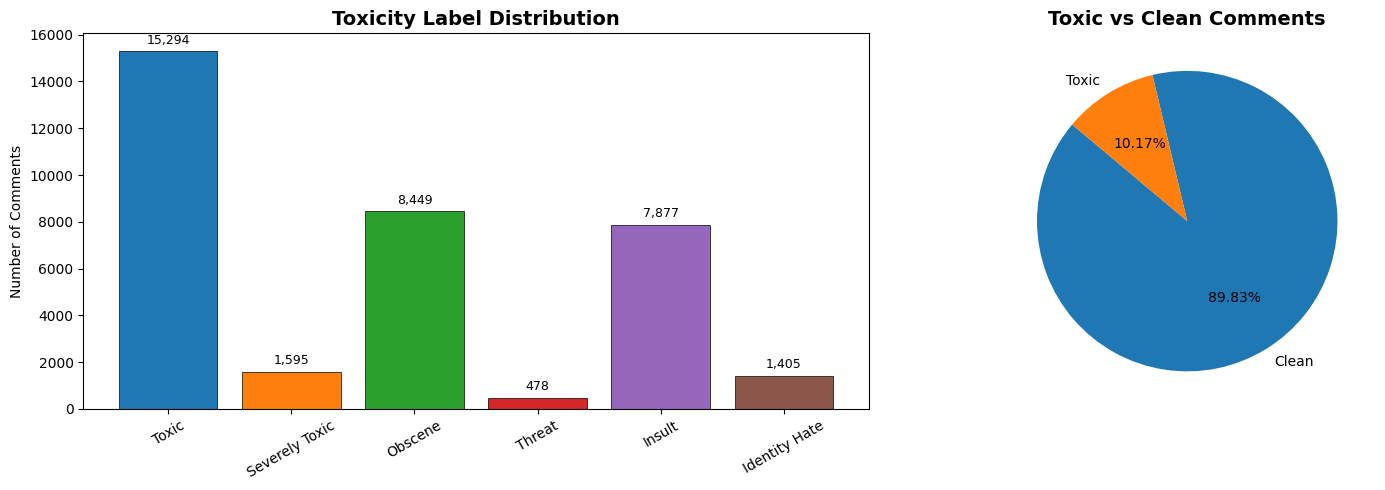

In [ ]:
# Plot 1: Label distribution + toxic vs clean ratio

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Generate a color list from the colormap 'tab10'
colors = plt.cm.tab10(range(len(LABEL_NAMES)))

axes[0].bar(LABEL_NAMES, label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Toxicity Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Comments')
axes[0].tick_params(axis='x', rotation=30)

for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Overall toxic vs clean split, the dataset is dominated by clean comments (~90%)
toxic_count = (df_raw[LABEL_COLS].sum(axis=1) > 0).sum()
clean_count  = len(df_raw) - toxic_count

axes[1].pie(
    [clean_count, toxic_count],
    labels=['Clean', 'Toxic'],
    autopct='%1.2f%%',
    colors=colors, # i know, but it works
    startangle=140
)
axes[1].set_title('Toxic vs Clean Comments', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'eda_label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

Il grafico a barre rivela un grave problema di sbilanciamento: la classe `toxic` domina (~15k), mentre `severe_toxic`, `threat` e `identity_hate` hanno meno di 2k campioni. Un modello addestrato con una standard Binary Cross-Entropy (BCE) su questi dati tenderebbe a predire sempre 0 per le classi rare.

Il grafico a torta rileva che ~90% del dataset è composto da commenti `Clean`.


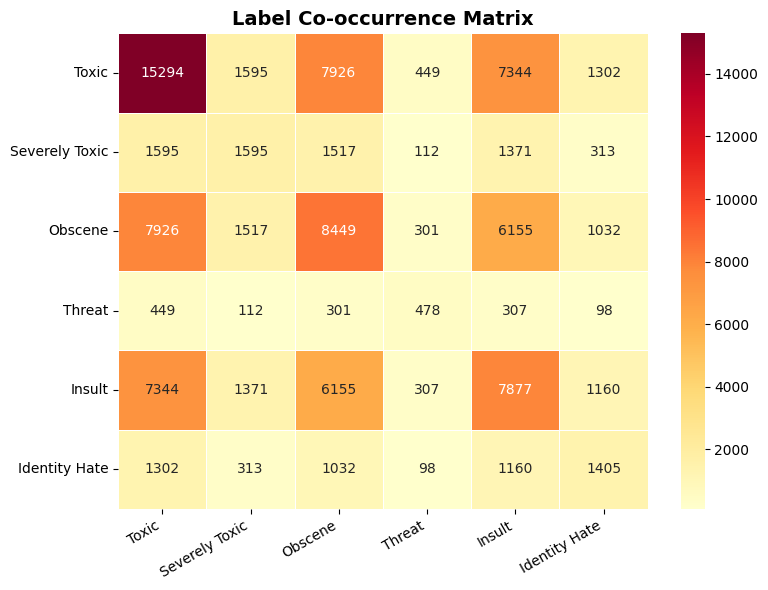

In [ ]:
# Plot 2: Label co-occurrence heatmap

# The diagonal shows total positives per class.
# Off-diagonal values show how often two labels appear together.

co_matrix = df_raw[LABEL_COLS].T.dot(df_raw[LABEL_COLS])

plt.figure(figsize=(8, 6))

sns.heatmap(
    co_matrix, annot=True,
    fmt='d', cmap='YlOrRd',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    linewidths=0.5
)

plt.title('Label Co-occurrence Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'eda_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()

La matrice di co-occorrenza evidenzia forti correlazioni positive tra specifiche categorie di tossicità. In particolare, notiamo un legame molto stretto tra `toxic`, `obscene` e `insult`: un commento classificato come insulto ha altissime probabilità di essere anche tossico e osceno.

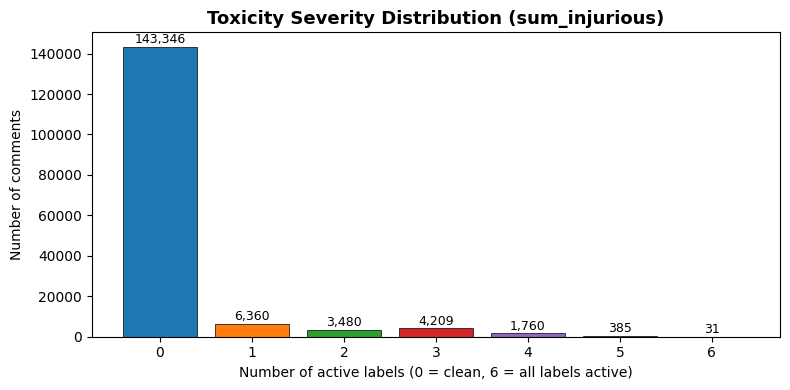

Severity breakdown:
 0 active labels: 143346 comments (89.83%)
 1 active labels: 6360 comments (3.99%)
 2 active labels: 3480 comments (2.18%)
 3 active labels: 4209 comments (2.64%)
 4 active labels: 1760 comments (1.10%)
 5 active labels: 385 comments (0.24%)
 6 active labels: 31 comments (0.02%)


In [ ]:
# Plot 3: Toxicity severity distribution (sum_injurious)

# sum_injurious ranges from 0 (clean) to 6 (all labels active).
# This derived column is not used as a model target, but it's useful here to understand how many comments fall into each severity level.
fig, ax = plt.subplots(figsize=(8, 4))

# Generate a color list from the colormap 'tab10'
colors = plt.cm.tab10(range(len(LABEL_NAMES)))

severity_counts = df_raw['sum_injurious'].value_counts().sort_index()

bars = ax.bar(
    severity_counts.index.astype(str),
    severity_counts.values,
    color=colors,
    edgecolor='black', linewidth=0.5
)

ax.set_title('Toxicity Severity Distribution (sum_injurious)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of active labels (0 = clean, 6 = all labels active)')
ax.set_ylabel('Number of comments')

for bar, v in zip(bars, severity_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 300, f'{v:,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'eda_severity.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Severity breakdown:")
for k, v in severity_counts.items():
    pct = v / len(df_raw) * 100
    print(f" {k} active labels: {v} comments ({pct:.2f}%)")

Questa visualizzazione analizza la "gravità" dei commenti calcolando quanti tag possiede contemporaneamente un singolo testo. La maggior parte dei commenti offensivi rientra in una sola categoria (principalmente la macro-categoria `toxic`), ma una fetta significativa accumula due o tre etichette simultaneamente.

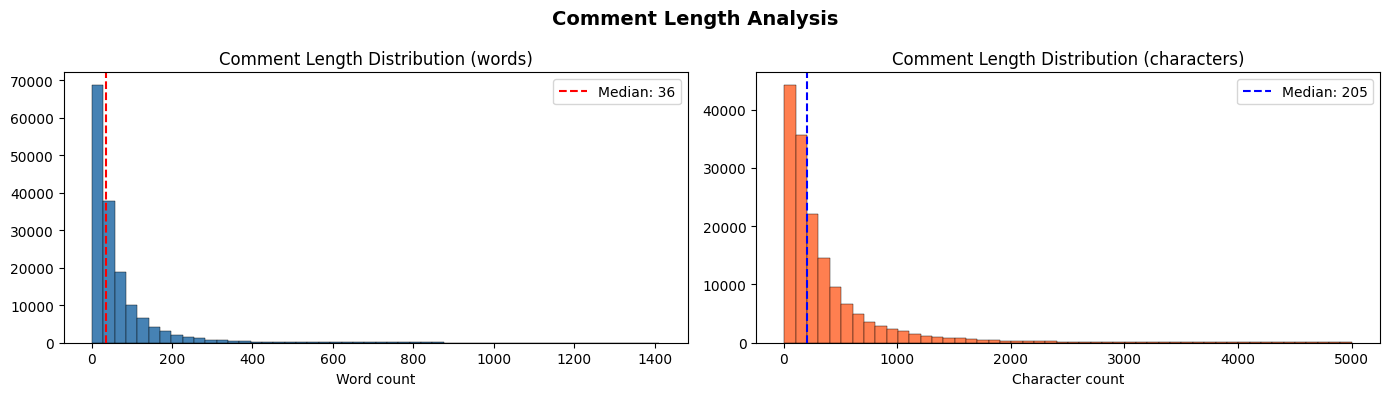


Word count statistics:
count    159571.00
mean         67.27
std          99.23
min           1.00
25%          17.00
50%          36.00
75%          75.00
max        1411.00
Name: text_length, dtype: float64

Quantile .95 text_lenght: 230.0

Character count statistics:
count    159571.00
mean        394.07
std         590.72
min           6.00
25%          96.00
50%         205.00
75%         435.00
max        5000.00
Name: char_length, dtype: float64

Quantile .95 char_length: 1355.0


In [ ]:
# Plot 4: Comment length distribution

# Exploratory analysis of raw comment lengths.
# Note: this plot uses df_raw (uncleaned text) and is for general orientation only.
# MAX_LEN is determined in another section from the cleaned training set (texts_train),
# ensuring the hyperparameter reflects the actual distribution seen by the model.

_df_tmp = df_raw.copy()

_df_tmp['text_length'] = _df_tmp['comment_text'].apply(lambda x: len(str(x).split()))
_df_tmp['char_length'] = _df_tmp['comment_text'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(_df_tmp['text_length'], bins=50, color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].axvline(_df_tmp['text_length'].median(), color='red', linestyle='--',
                label=f'Median: {_df_tmp["text_length"].median():.0f}')
axes[0].set_title('Comment Length Distribution (words)', fontsize=12)
axes[0].set_xlabel('Word count')
axes[0].legend()

axes[1].hist(_df_tmp['char_length'], bins=50, color='coral', edgecolor='black', linewidth=0.3)
axes[1].axvline(_df_tmp['char_length'].median(), color='blue', linestyle='--',
                label=f'Median: {_df_tmp["char_length"].median():.0f}')
axes[1].set_title('Comment Length Distribution (characters)', fontsize=12)
axes[1].set_xlabel('Character count')
axes[1].legend()

plt.suptitle('Comment Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'comment_length_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nWord count statistics:")
print(_df_tmp['text_length'].describe().round(2))
print(f"\nQuantile .95 text_lenght: {_df_tmp['text_length'].quantile(0.95)}")

print("\nCharacter count statistics:")
print(_df_tmp['char_length'].describe().round(2))
print(f"\nQuantile .95 char_length: {_df_tmp['char_length'].quantile(0.95)}")

**Lunghezze (testo grezzo):** La distribuzione è fortemente asimmetrica a destra (skewness positiva): la mediana è 36 parole ma la media è ~67, con una coda che arriva a 1.411. Il 95° percentile è **230 parole**.

In [ ]:
print(f"raw shape: {df_raw.shape}")
print(f"tmp shape: {_df_tmp.shape}")

del _df_tmp

raw shape: (159571, 8)
tmp shape: (159571, 10)


Il dataframe temporaneo `_df_tmp` usato per il Plot 4 è stato rimosso dalla memoria.

---
## 3. Preprocessing del Testo

Il preprocessing testuale è un passaggio critico: la qualità dell'input determina direttamente la qualità delle rappresentazioni apprese dall'Embedding layer.

**Scelte di design della pipeline `clean_text`:**

| Operazione | Motivazione |
|---|---|
| Lowercase | Riduce il vocabolario: "Abaco" e "abaco" diventano lo stesso token |
| Rimozione URL | Gli URL non portano segnale di tossicità |
| Rimozione HTML tags | Il dataset proviene da forum: `<br>`, `<b>` etc. sono rumore |
| Rimozione menzioni/hashtag | `@user` è anonimizzato, non aggiunge informazione |
| **Mantenimento `!` e `?`** | Marcatori di intensità emotiva: `"idiot!!!"` è più aggressivo di `"idiot"` |
| Mantenimento apostrofi | Contrazioni come `you're`, `don't` portano informazione grammaticale |
| Normalizzazione spazi | Evita token vuoti che aumenterebbero il padding inutilmente |

Il risultato viene salvato in `df_cleaned`, lasciando `df_raw` intatto.

In [ ]:
def clean_text(text: str) -> str:
    """
    Normalize and clean raw comment text for model ingestion.

    Design choice - punctuation preserved:
        '!' and '?' are retained as explicit tokens; emotional intensity
        these markers can be strong signals for toxicity ("idiot!!!" != "idiot")
        Apostrophes are kept for contractions ("don't", "you're").
        All other special characters and digits are removed.

    Steps:
        1. Lowercase
        2. URL removal
        3. HTML tag stripping
        4. @mention and #hashtag removal
        5. Remove all chars except letters, spaces, apostrophes, ! and ?
        6. Whitespace normalization

    Args:
        text: Raw comment string.
    Returns:
        Cleaned string ready for tokenization.
    """
    text = str(text).lower()                         # lower case
    text = re.sub(r'http\S+|www\.\S+', ' ', text)    # remove URLs
    text = re.sub(r'<.*?>', ' ', text)               # strip HTML tags
    text = re.sub(r'[@#]\w+', ' ', text)             # remove @mentions and #hashtags
    text = re.sub(r"[^a-z\s\'!?]", ' ', text)        # keep letters, apostrophes, ! and ?
    text = re.sub(r'\s+', ' ', text).strip()         # normalize whitespace
    return text

In [ ]:
# Apply cleaning and store in df_cleaned, df_raw is never modified
df_cleaned = df_raw.copy()

print("Applying text cleaning pipeline...")
df_cleaned['clean_text'] = df_cleaned['comment_text'].apply(clean_text)

# Drop rows that became empty or near-empty after cleaning
n_before   = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['clean_text'].str.len() > 3].reset_index(drop=True)
print(f"Rows dropped (empty after cleaning): {n_before - len(df_cleaned)}")
print(f"df_raw shape:     {df_raw.shape}")
print(f"df_cleaned shape: {df_cleaned.shape}")

Applying text cleaning pipeline...
Rows dropped (empty after cleaning): 35
df_raw shape:     (159571, 8)
df_cleaned shape: (159536, 9)


In [ ]:
df_cleaned.head(5)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,sum_injurious,clean_text
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0,hey man i'm really not trying to edit war it's...
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0,more i can't make any real suggestions on impr...
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0,you sir are my hero any chance you remember wh...


In [ ]:
# Sample comparison: verify cleaning preserves relevant signals
print("\nOriginal vs cleaned examples:")

random_samples = df_cleaned.sample(5)

for index, row in random_samples.iterrows():
    print("===" * 30)
    print(f"  [Original]: {row['comment_text'][:150]}")
    print("---" * 30)
    print(f"  [Cleaned]: {row['clean_text'][:150]}\n")


Original vs cleaned examples:
  [Original]: "
 You can think what you like about him, even if what you're saying is right (and I don't agree with it), you still can't express your POV. You don't
------------------------------------------------------------------------------------------
  [Cleaned]: you can think what you like about him even if what you're saying is right and i don't agree with it you still can't express your pov you don't go to a

  [Original]: "

RFA Thanks

Gidonb, I'd like to thank you for voting in my RFA. Thanks also for expressing your trust in me, and I hope that I live up to your expe
------------------------------------------------------------------------------------------
  [Cleaned]: rfa thanks gidonb i'd like to thank you for voting in my rfa thanks also for expressing your trust in me and i hope that i live up to your expectation

  [Original]: "

 Ambiguous phrase 

""Wilson initially suggested Charlie Chaplin or Adolf Hitler, whom Glass outright rejected

Gli esempi mostrano che la pipeline preserva correttamente il contenuto semantico dei commenti. Le contrazioni (`i'm`,`you're`, `don't`) vengono mantenute grazie alla conservazione degli apostrofi. I newline e le virgolette di apertura vengono eliminati. Il `df_raw` rimane immutato; Al `df_cleaned` viene aggiunta la colonna `clean_text` e vengono scartate 35 righe diventate vuote dopo il cleaning.

---
## 4. Split Stratificato Multi-label

### Splitting data prima della tokenizzazione
Il tokenizer deve essere fittato **solo** sul testo di training. Fittarlo sull'intero dataset espone il vocabolario ai token di val/test (**vocabulary leakage**).

### Perché la stratificazione multi-label?
Con uno split casuale semplice, classi rare come `threat` (< 1% del dataset) potrebbero essere distribuite in modo disomogeneo. L'algoritmo **Iterative Stratification** proposto da [Sechidis et al., 2011](https://www.researchgate.net/publication/220699691_On_the_Stratification_of_Multi-label_Data) garantisce che la proporzione di ogni label sia preservata in tutti e tre i set.

### Nomenclatura dei set
Lo split produce array NumPy perché le operazioni di tokenizzazione e padding operano su array di stringhe. Il mapping con `df_cleaned` rimane disponibile tramite gli indici originali se necessario.

In [ ]:
texts_all = df_cleaned['clean_text'].values
y_all = df_cleaned[LABEL_COLS].values.astype(np.float32)

# Step 1: hold out 15% as test set (stratified)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(msss.split(texts_all, y_all))

texts_temp, y_temp = texts_all[train_val_idx], y_all[train_val_idx]
texts_test, y_test = texts_all[test_idx], y_all[test_idx]

# Step 2: split remaining 85% into ~70% train + ~15% val (stratified)
# test_size = 0.15 / 0.85 ≈ 0.1765 to get exactly 15% of full dataset
msss_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.1765, random_state=SEED)
train_idx, val_idx = next(msss_2.split(texts_temp, y_temp))

texts_train, y_train = texts_temp[train_idx], y_temp[train_idx]
texts_val, y_val = texts_temp[val_idx], y_temp[val_idx]

print(f"Train: {len(texts_train)} ({len(texts_train)/len(texts_all)*100:.2f}%)")
print(f"Validation: {len(texts_val)} ({len(texts_val)/len(texts_all)*100:.2f}%)")
print(f"Test: {len(texts_test)} ({len(texts_test)/len(texts_all)*100:.2f}%)")

# Verify stratification: label proportions should be consistent across splits
print("\nLabel positive rate per split (stratification check):")
print(f"{'Label':>15} | {'Full':>6} | {'Train':>6} | {'Val':>6} | {'Test':>6}")
print("-" * 50)
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:>15} | {y_all[:,i].mean():.4f} | {y_train[:,i].mean():.4f} | {y_val[:,i].mean():.4f} | {y_test[:,i].mean():.4f}")


Train: 111670 (70.00%)
Validation: 23935 (15.00%)
Test: 23931 (15.00%)

Label positive rate per split (stratification check):
          Label |   Full |  Train |    Val |   Test
--------------------------------------------------
          Toxic | 0.0959 | 0.0959 | 0.0959 | 0.0959
 Severely Toxic | 0.0100 | 0.0100 | 0.0100 | 0.0100
        Obscene | 0.0530 | 0.0530 | 0.0530 | 0.0529
         Threat | 0.0030 | 0.0030 | 0.0030 | 0.0030
         Insult | 0.0494 | 0.0494 | 0.0494 | 0.0494
  Identity Hate | 0.0088 | 0.0088 | 0.0088 | 0.0088


**Verifica stratificazione:** La tabella mostra che le proporzioni di positivi per ogni label sono praticamente identiche in Full, Train, Val e Test (scostamento massimo < 0.0001 per `threat` nel `Test`).

---
## 5. EDA Post-Cleaning e Selezione Data-Driven degli Iperparametri

Il cleaning modifica significativamente le lunghezze dei testi (rimuove URL, HTML, caratteri speciali). Usare le statistiche su `df_raw` per scegliere `MAX_LEN` significa basarsi su una distribuzione che il modello non vedrà mai.

Tutta l'analisi viene eseguita esclusivamente su `texts_train` (training set pulito) per evitare data leakage nella scelta degli iperparametri.

- **`MAX_LEN`** = 95° percentile delle lunghezze del training set pulito, arrotondato alla decina più vicina
- **`MAX_VOCAB`** = dimensione del vocabolario che copre il 99% delle occorrenze di token.
- **`EMBED_DIM`** = 128 (default)

Word length stats - cleaned training text (texts_train):
 Mean: 66.7 | p50: 35 | p90: 151 | p95: 228 | p99: 569 


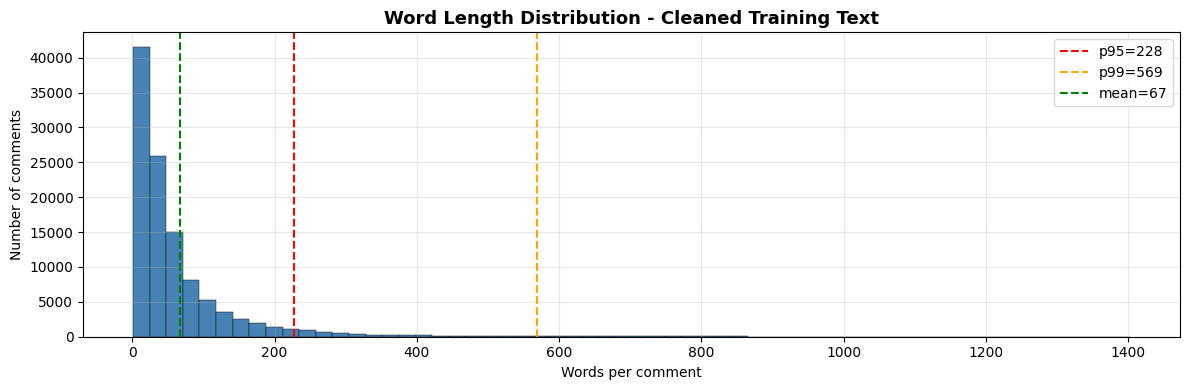

In [ ]:
# Plot 5: Length distribution on CLEANED training text

train_word_lengths = np.array([len(t.split()) for t in texts_train])

p50 = int(np.percentile(train_word_lengths, 50))
p90 = int(np.percentile(train_word_lengths, 90))
p95 = int(np.percentile(train_word_lengths, 95))
p99 = int(np.percentile(train_word_lengths, 99))
mean = train_word_lengths.mean()

print("Word length stats - cleaned training text (texts_train):")
print(f" Mean: {mean:.1f} | p50: {p50} | p90: {p90} | p95: {p95} | p99: {p99} ")

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(train_word_lengths, bins=60, color='steelblue', edgecolor='black', linewidth=0.3)

ax.axvline(p95,  color='red',    linestyle='--', linewidth=1.5, label=f'p95={p95}')
ax.axvline(p99,  color='orange', linestyle='--', linewidth=1.5, label=f'p99={p99}')
ax.axvline(mean, color='green',  linestyle='--',  linewidth=1.5, label=f'mean={mean:.0f}')

ax.set_title('Word Length Distribution - Cleaned Training Text', fontsize=13, fontweight='bold')
ax.set_xlabel('Words per comment')
ax.set_ylabel('Number of comments')

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'eda_post_cleaning_lengths.png'), dpi=150, bbox_inches='tight')
plt.show()

Il 95% dei commenti nel training set pulito ha una lunghezza inferiore a 228 parole. Pertanto, fisseremo il nostro MAX_LEN a 230, troncando il 5% dei commenti più lunghi.

Total unique words in training set: 145245
90% coverage: 4643 words
95% coverage: 12785 words
96% coverage: 17246 words
97% coverage: 24801 words
98% coverage: 39246 words
99% coverage: 70844 words


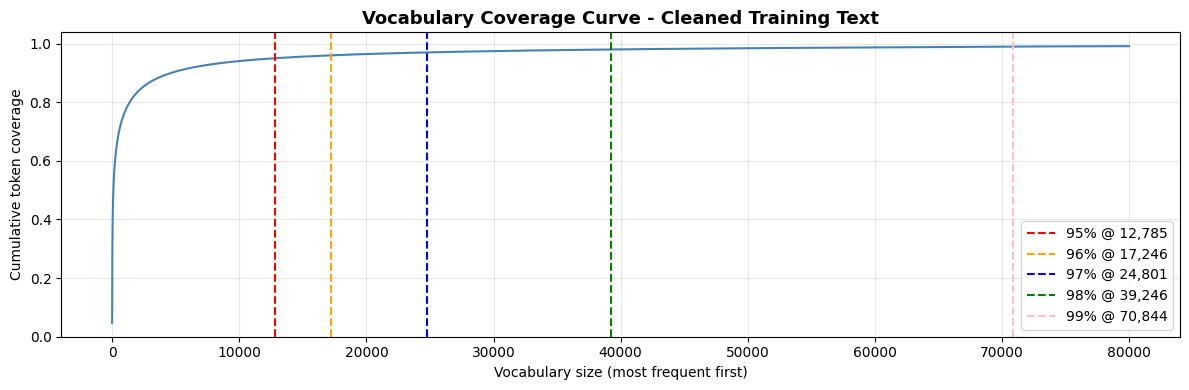

In [ ]:
# Plot 6: Vocabulary coverage analysis (temporary full tokenizer)
# Fit without vocab cap to inspect the long tail of rare words.
# This tokenizer is for analysis only.
_tok_full = Tokenizer(oov_token='<OOV>', lower=True)
_tok_full.fit_on_texts(texts_train)

total_vocab = len(_tok_full.word_index)
word_counts = sorted(_tok_full.word_counts.values(), reverse=True)
cumulative  = np.cumsum(word_counts) / sum(word_counts)

vocab_90 = int(np.searchsorted(cumulative, 0.90)) + 1
vocab_95 = int(np.searchsorted(cumulative, 0.95)) + 1
vocab_96 = int(np.searchsorted(cumulative, 0.96)) + 1
vocab_97 = int(np.searchsorted(cumulative, 0.97)) + 1
vocab_98 = int(np.searchsorted(cumulative, 0.98)) + 1
vocab_99 = int(np.searchsorted(cumulative, 0.99)) + 1

print(f"Total unique words in training set: {total_vocab}")
print(f"90% coverage: {vocab_90} words")
print(f"95% coverage: {vocab_95} words")
print(f"96% coverage: {vocab_96} words")
print(f"97% coverage: {vocab_97} words")
print(f"98% coverage: {vocab_98} words")
print(f"99% coverage: {vocab_99} words")

x_range = np.arange(1, min(total_vocab + 1, 80000))

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x_range, cumulative[:len(x_range)], color='steelblue', linewidth=1.5)

ax.axvline(vocab_95, color='red',    linestyle='--', linewidth=1.5, label=f'95% @ {vocab_95:,}')
ax.axvline(vocab_96, color='orange', linestyle='--', linewidth=1.5, label=f'96% @ {vocab_96:,}')
ax.axvline(vocab_97, color='blue', linestyle='--', linewidth=1.5, label=f'97% @ {vocab_97:,}')
ax.axvline(vocab_98, color='green', linestyle='--', linewidth=1.5, label=f'98% @ {vocab_98:,}')
ax.axvline(vocab_99, color='pink', linestyle='--', linewidth=1.5, label=f'99% @ {vocab_99:,}')

ax.set_title('Vocabulary Coverage Curve - Cleaned Training Text', fontsize=13, fontweight='bold')
ax.set_xlabel('Vocabulary size (most frequent first)')
ax.set_ylabel('Cumulative token coverage')
ax.legend()

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'eda_vocab_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()

del _tok_full

Il grafico illustra il principio della long-tail (o **[Legge di Zipf](https://en.wikipedia.org/wiki/Brevity_law)**) applicato al nostro corpus testuale. Un sottoinsieme relativamente piccolo delle parole più frequenti è sufficiente a coprire oltre il 99% del testo totale presente nel dataset. Tutte le parole rimanenti (la lunga coda a destra) sono termini rarissimi, refusi tipografici o neologismi unici che non portano potere predittivo generalizzabile. Grazie a questa evidenza, possiamo impostare un `MAX_VOCAB` mirato, riducendo le dimensioni della matrice di Embedding senza degradare le performance del modello.

In [ ]:
# Data-driven hyperparameter selection

# MAX_LEN   = p95 of cleaned training lengths, rounded up to nearest 10.
# MAX_VOCAB = 99% token coverage.
# EMBED_DIM = 128 (principled default, not data-driven by design)
MAX_LEN   = int(np.ceil(p95 / 10) * 10)
MAX_VOCAB = vocab_99
EMBED_DIM = 128

print(f"MAX_LEN   = {MAX_LEN}   (p95={p95} from texts_train, rounded up to nearest 10)")
print(f"MAX_VOCAB = {MAX_VOCAB}  (99% token coverage on texts_train)")
print(f"EMBED_DIM = {EMBED_DIM}   (principled default)")


MAX_LEN   = 230   (p95=228 from texts_train, rounded up to nearest 10)
MAX_VOCAB = 70844  (99% token coverage on texts_train)
EMBED_DIM = 128   (principled default)


**Scelte degli iperparametri:**

**`MAX_LEN = 230`:** Derivato dal 95° percentile delle lunghezze del training set pulito (p95=228, arrotondato a 230). La scelta del 95° percentile è una prassi consolidata nel preprocessing NLP: copre la quasi totalità dei commenti senza sprecare memoria su outlier estremi.

**`MAX_VOCAB = 70.844`:** Derivato dalla curva di copertura del vocabolario di training: è il numero minimo di parole (ordinate per frequenza decrescente) necessario a coprire il 99% delle occorrenze di token.

**`EMBED_DIM = 128`:** Default

---
## 6. Tokenizzazione, Padding e Focal Loss

### Perché Focal Loss invece di Weighted BCE?

La Weighted BCE con pesi calcolati come `w = n_neg/n_pos` produce coefficienti molto grandi per le classi rare (`severe_toxic`, `threat` e `identity_hate`). Questi pesi amplificano i gradienti in modo esplosivo nelle prime epoche, quando il modello produce output casuali vicini a 0.5, causando il potenziale collasso durante il training.

**Focal Loss** ([Lin et al., 2017 - Focal Loss for Dense Object Detection](https://arxiv.org/abs/1708.02002)) risolve il problema alla radice, senza richiedere pesi espliciti. La formula è:

$$\text{FL}(p_t) = -\alpha_t \cdot (1 - p_t)^{\gamma} \cdot \log(p_t)$$


dove $p_t$ è la probabilità predetta per la classe corretta.

Il termine chiave è il **fattore di modulazione** $(1 - p_t)^{\gamma}$:
- Quando il modello classifica facilmente un esempio ($p_t \to 1$): $(1-p_t)^\gamma \to 0$ quindi il contributo alla loss è quasi zero
- Quando il modello sbaglia o è incerto ($p_t \to 0.5$): $(1-p_t)^\gamma \approx 1$ → la loss è piena

In pratica la Focal Loss **ignora automaticamente gli esempi facili** (i molti negativi puliti) e **concentra il gradiente sugli esempi difficili** (i positivi rari e i borderline), senza mai produrre gradienti esplosivi.

| Parametro | Valore | Motivazione |
|---|---|---|
| `gamma=2.0` | Standard dalla letteratura | $\gamma=0$ riduce a BCE standard; $\gamma=2$ è il valore ottimale per la maggior parte dei task sbilanciati |
| `alpha=0.25` | Standard dalla letteratura | Bilancia il contributo dei termini positivi e negativi; valore empiricamente validato su numerosi benchmark |

### Nota sul Bilanciamento dei Dati (Riferimento ai requisiti di progetto):
La traccia suggerisce di bilanciare i dati per garantire equa rappresentanza. In questo progetto si è scelto consapevolmente di non applicare un bilanciamento fisico (Oversampling/Undersampling) perché, in un contesto multi-label, replicare o tagliare campioni altera le distribuzioni congiunte delle altre etichette, portando a overfitting o a perdita massiccia di informazione (undersampling della classe "clean").
Si è optato invece per uno stato dell'arte del bilanciamento algoritmico: la Focal Loss. Questa funzione di costo bilancia dinamicamente l'apprendimento penalizzando gli esempi facili e forzando il modello a concentrarsi sulle classi rare e difficili, soddisfacendo il requisito di progetto in modo matematicamente più solido.

In [ ]:
# Fit tokenizer on texts_train only, prevents vocabulary leakage to val/test
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>', lower=True)
tokenizer.fit_on_texts(texts_train)

vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB)
print(f"Vocabulary size passed to Embedding layer: {vocab_size}")

seq_train = tokenizer.texts_to_sequences(texts_train)
seq_val   = tokenizer.texts_to_sequences(texts_val)
seq_test  = tokenizer.texts_to_sequences(texts_test)

# 'post' padding: content at start, zeros at end - LSTM reads real tokens first
X_train = pad_sequences(seq_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(seq_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(seq_test,  maxlen=MAX_LEN, padding='post', truncating='post')

coverage = (np.array([len(s) for s in seq_train]) <= MAX_LEN).mean() * 100
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"MAX_LEN={MAX_LEN} covers {coverage:.2f}% of training sequences")


Vocabulary size passed to Embedding layer: 70844
X_train: (111670, 230) | X_val: (23935, 230) | X_test: (23931, 230)
MAX_LEN=230 covers 95.09% of training sequences


In [ ]:
# OOV diagnostic

oov_idx = tokenizer.word_index.get('<OOV>', 1)

def oov_rate(sequences: list) -> float:
    """Fraction of tokens mapped to the <OOV> index."""
    total = sum(len(s) for s in sequences)
    oov   = sum(t == oov_idx for s in sequences for t in s)
    return oov / total if total > 0 else 0.0

oov_train = oov_rate(seq_train)
oov_val   = oov_rate(seq_val)
oov_test  = oov_rate(seq_test)

print(f"OOV rate - train:    {oov_train:.2%}  (non-zero due to vocabulary cap at MAX_VOCAB)")
print(f"OOV rate - val:      {oov_val:.2%}")
print(f"OOV rate - test:     {oov_test:.2%}")
print(f"OOV delta val-train: {oov_val-oov_train:.2%}  (small delta = good vocab generalization)")


OOV rate - train:    1.00%  (non-zero due to vocabulary cap at MAX_VOCAB)
OOV rate - val:      2.02%
OOV rate - test:     1.96%
OOV delta val-train: 1.02%  (small delta = good vocab generalization)


**OOV rate:**

- **Train (1.00%):** Non-zero perché `MAX_VOCAB=70.844` non include tutte le parole del training corpus (vocabolario totale = 145.245). Le parole escluse, per definizione le meno frequenti, vengono mappate a `<OOV>`.
- **Val (2.02%) e Test (1.96%):** Leggermente superiori al training, come atteso: val e test contengono parole mai viste durante il fitting del tokenizer che vengono correttamente gestite dal token `<OOV>`. Un tasso OOV elevato indicherebbe un vocabolario troppo ristretto; ~2% è un valore sano.
- **Delta val-train (1.02%):** Un delta piccolo indica buona generalizzazione del vocabolario: il training corpus copre la quasi totalità delle parole presenti nei dati futuri, simulando correttamente lo scenario di produzione.

In [ ]:
# Class imbalance summary: informational only, not used in loss computation.

# With Focal Loss, explicit weights are not required: the modulating factor
# (1 - p_t)^gamma automatically down-weights easy negatives.
# These ratios motivate the choice of Focal Loss over standard BCE.

print(f"{'Label':>15} | {'Positives':>10} | {'Negatives':>10} | {'Ratio':>8}")
print("-" * 52)

for i, col in enumerate(LABEL_COLS):
    n_pos  = y_train[:, i].sum()
    n_neg  = len(y_train) - n_pos
    ratio = n_neg / (n_pos + 1e-6)    # epsilon prevents division by zero
    print(f"{LABEL_NAMES[i]:>15} | {n_pos:>10.0f} | {n_neg:>10.0f} | {ratio:>8.2f}x")


          Label |  Positives |  Negatives |    Ratio
----------------------------------------------------
          Toxic |      10705 |     100965 |     9.43x
 Severely Toxic |       1117 |     110553 |    98.97x
        Obscene |       5914 |     105756 |    17.88x
         Threat |        334 |     111336 |   333.34x
         Insult |       5513 |     106157 |    19.26x
  Identity Hate |        983 |     110687 |   112.60x


Come visibile dai dati precedenti, il rapporto per le classi `Threat` (333x), `Identity Hate` (112x) e `Severely Toxic` (98x) supera di gran lunga la soglia empirica (~50x) oltre la quale una Weighted BCE (Binary Cross-Entropy pesata) tende a produrre l'esplosione del gradiente.

La **Focal Loss** gestisce questa criticità in modo intrinseco grazie al suo fattore modulante $(1-p_t)^\gamma$

In [ ]:
def focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """

    Formula:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    where p_t = p if y=1 else (1-p), alpha_t = alpha if y=1 else (1-alpha).

    Key property - modulating factor (1 - p_t)^gamma:
        - Easy examples (p_t -> 1): factor -> 0, loss contribution ~0
        - Hard/uncertain examples (p_t -> 0.5): factor ~1, full loss

    Args:
        gamma: Focusing parameter: 0 = standard BCE, 2 = paper default.
        alpha: Balance factor. 0.25 = paper default.

    Returns:
        Keras-compatible loss function.
    """
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # p_t: probability of the correct class
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)

        # alpha_t: per-sample balance factor
        alpha_t = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)

        # Standard BCE computed from p_t
        bce = -tf.math.log(p_t)

        # Focal weight: down-weights easy examples
        focal_weight = alpha_t * tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(focal_weight * bce)

    loss.__name__ = 'focal_loss'
    return loss


# Instantiate with paper-default hyperparameters
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25
print(f"Focal Loss: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")
print("(gamma=0 reduces to standard BCE; alpha=0.25 is the RetinaNet paper default)")


Focal Loss: gamma=2.0, alpha=0.25
(gamma=0 reduces to standard BCE; alpha=0.25 is the RetinaNet paper default)


---
## 7. Architettura del Modello - Bidirectional LSTM

### Perché un'architettura ricorrente?
I commenti sono sequenze dove l'**ordine conta**. Gli LSTM mantengono uno stato nascosto aggiornato token per token, catturando dipendenze sequenziali impossibili per i modelli bag-of-words.

### Perché Bidirectional?
Una BiLSTM esegue due LSTM in parallelo (→ forward, ← backward) e concatena gli hidden states. Ogni token è contestualizzato da parole precedenti **e successive**.

### LSTM vs GRU - Confronto e Motivazione della Scelta
La traccia del progetto prevede l'utilizzo di LSTM **o** GRU. Entrambe le architetture sono progettate per gestire sequenze e risolvono il problema del **vanishing gradient** tramite meccanismi a gate, ma con strutture diverse:

| Aspetto | LSTM | GRU |
|---|---|---|
| Gate | 3 (forget, input, output) + cell state separato | 2 (reset, update) - nessun cell state separato |
| Parametri | ~4× il numero di unità² | ~3× il numero di unità² |
| Memoria a lungo termine | Cell state separato: più esplicita e controllabile | Implicita nell'hidden state |
| Velocità per epoca | Più lenta (più parametri) | ~25% più veloce a parità di unità |
| Performance empirica | Spesso superiore su sequenze lunghe | Comparabile su sequenze brevi/medie |

**Motivazione della scelta - LSTM:** I commenti hanno lunghezza mediana ~40 parole ma con code fino a centinaia di token (MAX_LEN=230). Il cell state separato dell'LSTM è vantaggioso per catturare dipendenze a lungo raggio. Su questo tipo di dataset la letteratura indica performance comparabili tra le due architetture; si è scelto LSTM per la sua maggiore capacità espressiva nella gestione di sequenze lunghe.

### Dettagli architetturali

| Layer | Output Shape | Motivazione |
|---|---|---|
| `Embedding` | `(batch, 230, 128)` | Rappresentazione densa appresa end-to-end. `mask_zero` **non utilizzato** per compatibilità cuDNN (vedi nota) |
| `SpatialDropout1D(0.3)` | `(batch, 230, 128)` | Dropout su interi canali embedding |
| `BiLSTM(128, return_seq=True)` | `(batch, 230, 256)` | 128×2 direzioni; `return_sequences=True` per lo stacking |
| `BatchNormalization` | `(batch, 230, 256)` | Stabilizza le attivazioni |
| `BiLSTM(64, return_seq=True)` | `(batch, 230, 128)` | Pattern compositivi di ordine superiore |
| `GlobalMaxPooling1D` | `(batch, 128)` | Seleziona il picco di attivazione lungo la sequenza |
| `Dense(128) + Dense(64)` | `(batch, 64)` | Classificatore con dropout |
| `Dense(6, sigmoid)` | `(batch, 6)` | **Sigmoid**: probabilità indipendenti - le label non sono mutualmente esclusive |


### Gradient Clipping
L'optimizer (`Adam`) usa `clipnorm=1.0`: il gradiente viene normalizzato a 1 prima di ogni aggiornamento dei pesi. Questa è una best practice standard per le reti ricorrenti (LSTM), indipendente dal tipo di loss, introdotta da [Pascanu et al. (2013)](https://arxiv.org/abs/1211.5063) per affrontare il problema del **gradient explosion** nelle sequenze lunghe. Il clipping preserva la direzione del gradiente, modificandone solo la norma quando necessario.

### Nota su `mask_zero` e compatibilità cuDNN
`mask_zero=True` nell'Embedding istruisce gli LSTM a ignorare i token di padding. Tuttavia, il layer `backward` della BiLSTM legge la sequenza al contrario, producendo una maschera `[False...True]` che il kernel cuDNN di TensorFlow rifiuta (supporta solo maschere `[True...False]`). Abilitarlo forzerebbe il fallback al kernel generico (più lento). La scelta di disabilitarlo è motivata da questo vincolo tecnico strutturale, con impatto trascurabile: con `padding='post'` e `GlobalMaxPooling1D`, i token di padding producono attivazioni sistematicamente più deboli e il max non li seleziona quasi mai.

In [ ]:
def build_bilstm_model(vocab_size: int,
                       embed_dim: int,
                       max_len: int,
                       num_labels: int,) -> 'tf.keras.Model':
    """
    Bidirectional LSTM for multi-label toxicity classification.

    Key design choices:
        - mask_zero=False: required for cuDNN compatibility.
        - Bidirectional: each token contextualized by past AND future tokens.
        - SpatialDropout1D: drops entire embedding channels, not individual values.
        - GlobalMaxPooling1D: selects strongest activation across time axis.
        - Sigmoid output: independent probability per label (multi-label setting).
        - Focal Loss: handles class imbalance without explicit weights.
        - clipnorm=1.0: standard gradient clipping for LSTM stability.

    Args:
        vocab_size, embed_dim, max_len, num_labels.
    Returns:
        Compiled Keras Model.
    """
    inputs = Input(shape=(max_len,), name='token_ids')

    x = Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  mask_zero=False, name='embedding')(inputs)
    x = SpatialDropout1D(0.3, name='spatial_dropout')(x)

    # recurrent_dropout=0.0 enables the cuDNN kernel (faster on my GPU)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
                      name='bilstm_1')(x)
    x = BatchNormalization(name='bn_1')(x)

    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
                      name='bilstm_2')(x)
    x = BatchNormalization(name='bn_2')(x)

    x = GlobalMaxPooling1D(name='global_max_pool')(x)

    x = Dense(128, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(0.4, name='dropout_1')(x)
    x = Dense(64, activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='dropout_2')(x)

    outputs = Dense(num_labels, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_AntiHater')
    model.compile(
        # clipnorm=1.0: gradient clipping: standard for LSTM, prevents exploding gradients
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss=focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                 tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model


model = build_bilstm_model(vocab_size, EMBED_DIM, MAX_LEN, len(LABEL_COLS))
model.summary()


Model: "BiLSTM_AntiHater"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)          │ (None, 230)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 230, 128)       │     9,068,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 230, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 230, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 230, 256)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 230, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 230, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,522,758 (36.33 MB)

 Trainable params: 9,521,734 (36.32 MB)

 Non-trainable params: 1,024 (4.00 KB)

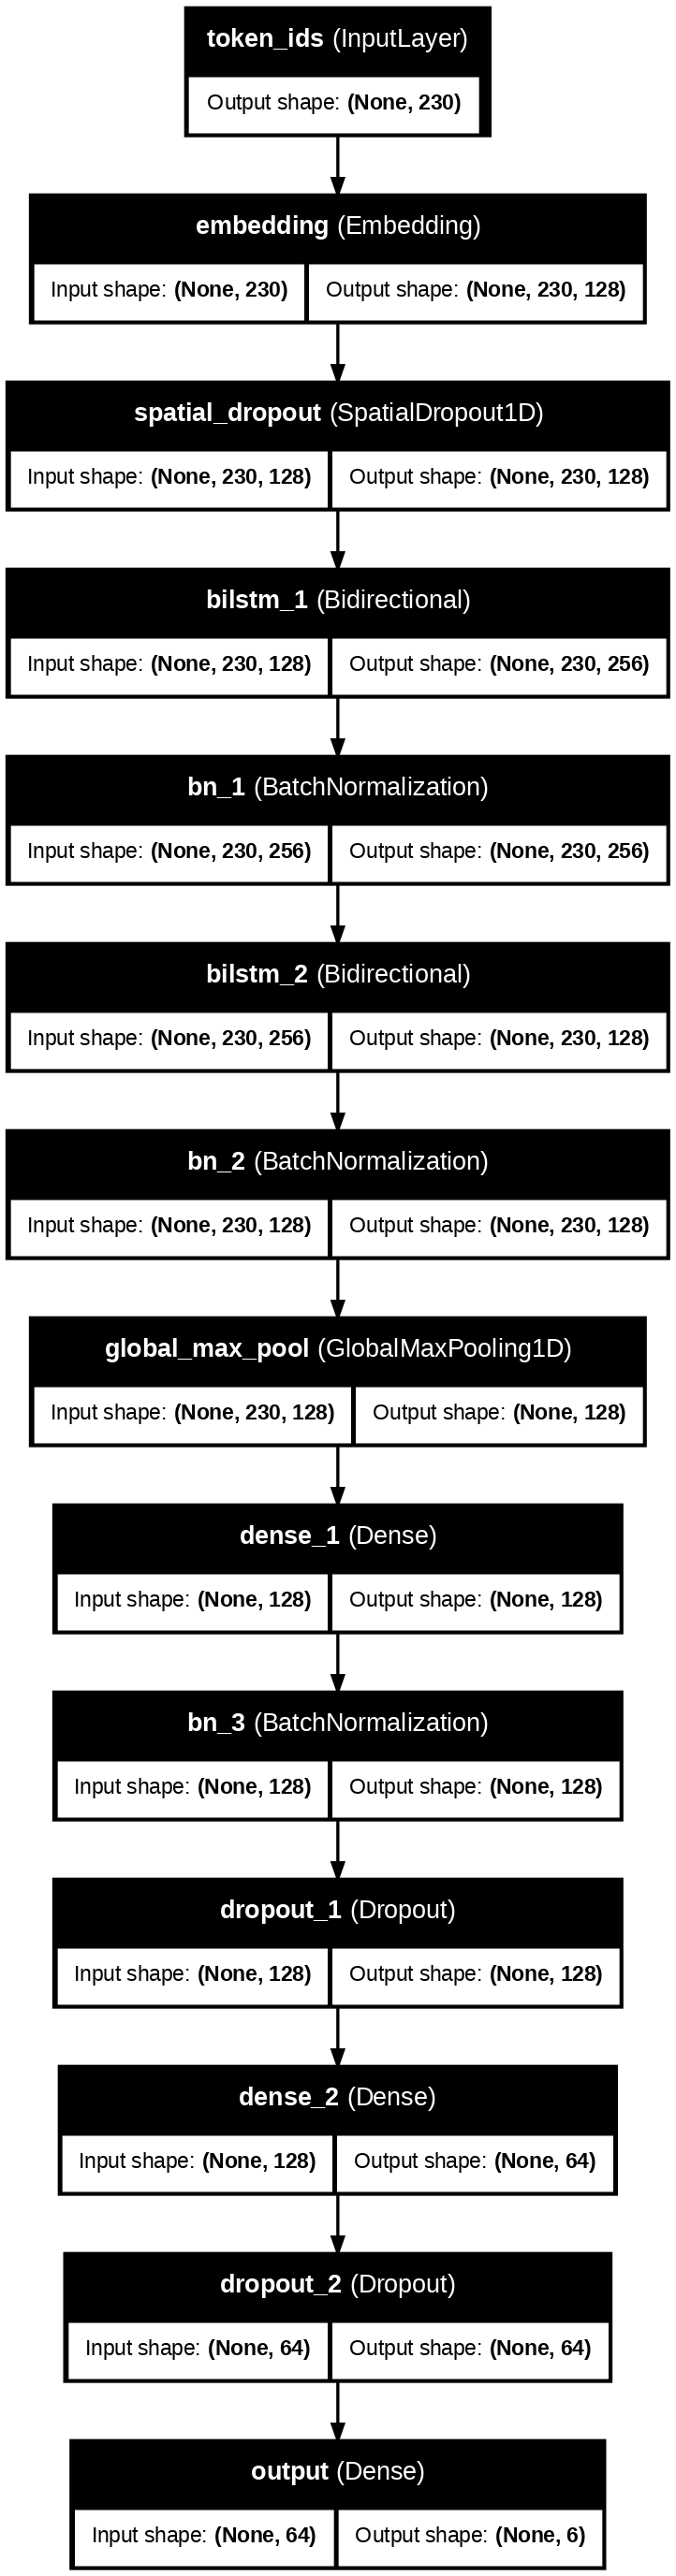

In [ ]:

try:
    output_path = os.path.join(DRIVE_OUTPUT, 'model_architecture.png')

    tf.keras.utils.plot_model(
        model,
        to_file=output_path,
        show_shapes=True,
        show_layer_names=True,
        dpi=120
    )

    from IPython.display import Image
    display(Image(output_path))

except Exception as e:
    print(f"Architecture plot unavailable: {e}")


---
## 8. Training del Modello - Ricerca del Batch Size Ottimale

Invece di fissare arbitrariamente un batch size, questa sezione esegue un **esperimento controllato** su due configurazioni (256, 128), selezionando la migliore tramite la metrica di validazione. Il modello vincitore viene salvato come `best_model.keras`: il file usato da tutte le sezioni successive.

### Separazione rigorosa tra selezione e valutazione

Il **test set** ha un unico scopo: stimare la performance del modello finale su dati mai visti. Usarlo per confrontare i batch size e scegliere il vincitore costituisce **data leakage indiretto**: si ottimizzerebbe implicitamente su di esso.

La selezione avviene quindi sul **validation set**, usando `best_val_auc`: il massimo AUC di validazione raggiunto durante il training. Questa metrica:
- È **threshold-free**: non dipende dalla soglia di binarizzazione, eliminando una fonte di varianza aggiuntiva
- È già **usata internamente** da `ModelCheckpoint` per salvare il checkpoint migliore di ogni run, è quindi coerente con la procedura di training
- Confronta i *massimi* val_auc tra run, non valori epoch-per-epoch (dove il rumore sarebbe più problematico)

Le metriche sul test set vengono comunque calcolate per ogni configurazione e mostrate nella tabella comparativa, ma con un'etichetta esplicita: sono informative, non determinano la selezione.

### Callback

**EarlyStopping** `(monitor='val_auc', patience=10, min_delta=1e-3)`  
Interrompe il training se l'AUC di validazione non migliora di almeno 0.001 per 10 epoche consecutive. `patience=10` (20% di `TUNE_EPOCHS=50`) lascia spazio al ReduceLROnPlateau di agire prima dell'arresto.

**ReduceLROnPlateau** `(monitor='val_loss', factor=0.5, patience=5)`  
Dimezza il LR ogni 5 epoche di stagnazione della `val_loss`.

**ModelCheckpoint** `(monitor='val_auc', save_best_only=True)`  
Salva il checkpoint con la migliore AUC di validazione - disaccoppia il modello ottimale dallo stato finale del training.

### Nota metodologica: Learning Rate e Batch Size
La *linear scaling rule* ([Goyal et al., 2017](https://arxiv.org/abs/1706.02677)) suggerisce di scalare il LR proporzionalmente al batch size. Il LR iniziale è mantenuto fisso (1e-3) per tutte le configurazioni: una semplificazione consapevole che isola l'effetto del solo batch size, ma che potrebbe penalizzare il batch size più grande.


In [ ]:
BATCH_SIZES = [256, 128] # reduced from [256, 128, 64, 32] because Colab terminated the runtime: maximum time exceeded
TUNE_EPOCHS = 50  # upper bound

tune_results   = []  # comparison table built inside the loop
tune_histories = {}  # training History objects keyed by batch size

# Compute once outside the loop, identical for every batch size
y_test_int = y_test.astype(int)

for bs in BATCH_SIZES:

    print(f"\n{'='*60}")
    print(f"  Training with batch_size={bs}")
    print(f"{'='*60}")

    # Fresh model for each batch size.
    # Note: tf.random.set_seed alone does not guarantee identical weight
    # initialization across multiple model builds in the same session.
    # We accept this variance as inherent to the experiment.
    tf.random.set_seed(SEED)
    tune_model = build_bilstm_model(vocab_size, EMBED_DIM, MAX_LEN, len(LABEL_COLS))

    ckpt_path = os.path.join(DRIVE_OUTPUT, f'tune_model_bs{bs}.keras')

    tune_callbacks = [
        EarlyStopping(monitor='val_auc', mode='max', patience=10,
                      min_delta=1e-3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-6, verbose=0),
        ModelCheckpoint(filepath=ckpt_path, monitor='val_auc', mode='max',
                        save_best_only=True, verbose=0)
    ]

    hist = tune_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=bs,
        epochs=TUNE_EPOCHS,
        callbacks=tune_callbacks,
        verbose=1
    )

    tune_histories[bs] = hist
    epochs_run   = len(hist.history['val_auc'])
    best_val_auc = max(hist.history['val_auc'])  # selection criterion
    print(f"  Stopped at epoch {epochs_run} | best_val_auc={best_val_auc:.4f}")

    # Test set evaluation - informational only, NOT used for model selection

    loaded = tf.keras.models.load_model(
        ckpt_path,
        custom_objects={'focal_loss': focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)}
    )

    # Threshold optimization on VAL set
    val_probs  = loaded.predict(X_val,  batch_size=512, verbose=0)
    test_probs = loaded.predict(X_test, batch_size=512, verbose=0)

    opt_thr = []
    for i in range(len(LABEL_COLS)):
        best_thr, best_f1 = 0.5, 0.0

        for thr in np.arange(0.2, 0.8, 0.01):
            preds = (val_probs[:, i] >= thr).astype(int)
            f1    = f1_score(y_val[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        opt_thr.append(best_thr)

    test_binary = np.zeros_like(test_probs, dtype=int)

    for i, thr in enumerate(opt_thr):
        test_binary[:, i] = (test_probs[:, i] >= thr).astype(int)

    test_f1_macro = f1_score(y_test_int, test_binary, average='macro',    zero_division=0)
    test_f1_micro = f1_score(y_test_int, test_binary, average='micro',    zero_division=0)
    test_auc      = roc_auc_score(y_test_int, test_probs, average='macro')
    test_hamming  = hamming_loss(y_test_int, test_binary)

    tune_results.append({
        'batch_size':          bs,
        'epochs_run':          epochs_run,
        'best_val_auc':        round(best_val_auc,  4),  # SELECTION CRITERION
        'test_f1_macro':       round(test_f1_macro, 4),  # informational only
        'test_f1_micro':       round(test_f1_micro, 4),  # informational only
        'test_auc_macro':      round(test_auc,      4),  # informational only
        'test_hamming':        round(test_hamming,   4), # informational only
        'ckpt_path':           ckpt_path,
    })

    print(f"  [informational] test F1 macro={test_f1_macro:.4f} "
          f"| AUC={test_auc:.4f} | Hamming={test_hamming:.4f}")

    # Free GPU memory before next training
    del tune_model, loaded



  Training with batch_size=256
Epoch 1/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 95s 183ms/step - accuracy: 0.9461 - auc: 0.7348 - loss: 0.0246 - val_accuracy: 0.9646 - val_auc: 0.9417 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 2/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 79s 182ms/step - accuracy: 0.9747 - auc: 0.9458 - loss: 0.0067 - val_accuracy: 0.9789 - val_auc: 0.9696 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.9780 - auc: 0.9652 - loss: 0.0055 - val_accuracy: 0.9797 - val_auc: 0.9697 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.9787 - auc: 0.9685 - loss: 0.0053 - val_accuracy: 0.9735 - val_auc: 0.9554 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 5/50
437/437 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.9797 - auc: 0.9742 - loss: 0.0048 - val_accuracy: 0.9793 - val_auc: 0.9657 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 6/50
437/437 ━━━━━━━━━━━━━━

In [ ]:
# Comparison table (sorted by best_val_auc)

df_tune = (pd.DataFrame(tune_results)
             .sort_values('best_val_auc', ascending=False)
             .reset_index(drop=True))

print("Batch Size Comparison")
print("Selection criterion: best_val_auc (threshold-free, val set only)")
print("Test metrics: informational - not used for selection")
print("=" * 75)
print(df_tune[['batch_size', 'epochs_run', 'best_val_auc',
               'test_f1_macro', 'test_auc_macro', 'test_hamming']].to_string(index=False))
print("=" * 75)

df_tune.to_csv(os.path.join(DRIVE_OUTPUT, 'batch_size_comparison.csv'), index=False)

# Identify winner by validation metric
best_row = df_tune.iloc[0]  # first row = highest best_val_auc
best_bs  = int(best_row['batch_size'])

print(f"\nWinner: batch_size={best_bs} "
      f"(best_val_auc={best_row['best_val_auc']:.4f}, "
      f"epochs={int(best_row['epochs_run'])})")
print(f"[informational] winner test_f1_macro={best_row['test_f1_macro']:.4f} "
      f"| test_auc={best_row['test_auc_macro']:.4f}")
print("Note: final unbiased test metrics will be computed in another Section.")

# Copy winner checkpoint - all downstream cells use 'best_model.keras'
winner_dst = os.path.join(DRIVE_OUTPUT, 'best_model.keras')
shutil.copy(best_row['ckpt_path'], winner_dst)
print(f"Winner checkpoint copied to: {winner_dst}")


Batch Size Comparison
Selection criterion: best_val_auc (threshold-free, val set only)
Test metrics: informational — not used for selection
 batch_size  epochs_run  best_val_auc  test_f1_macro  test_auc_macro  test_hamming
        256          12        0.9697         0.5275          0.9752        0.0235
        128          12        0.9692         0.5140          0.9728        0.0239

Winner: batch_size=256 (best_val_auc=0.9697, epochs=12)
[informational] winner test_f1_macro=0.5275 | test_auc=0.9752
Note: final unbiased test metrics will be computed in another Section.
Winner checkpoint copied to: /content/drive/MyDrive/Progetto_DL_Filtro_Anti-Hater_Carleo_G/best_model.keras


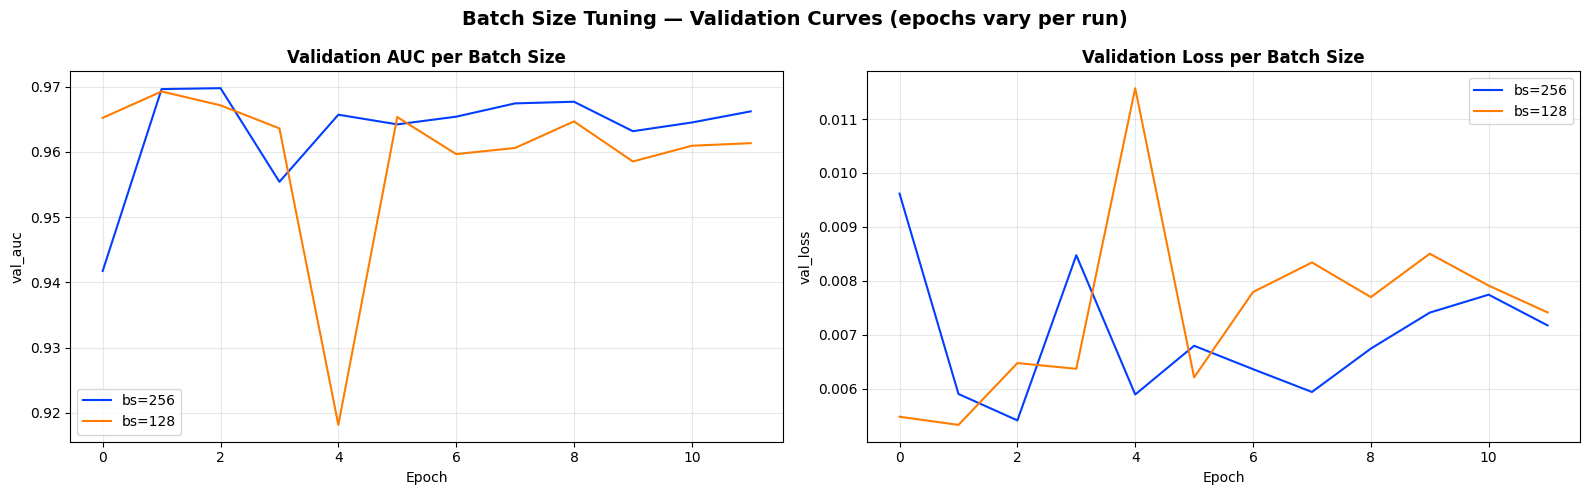

In [ ]:
# Plot 7: val_auc and val_loss training curves for all batch sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette('bright', len(BATCH_SIZES))

for color, bs in zip(palette, BATCH_SIZES):
    h = tune_histories[bs].history
    axes[0].plot(h['val_auc'],  label=f'bs={bs}', color=color, linewidth=1.5)
    axes[1].plot(h['val_loss'], label=f'bs={bs}', color=color, linewidth=1.5)

axes[0].set_title('Validation AUC per Batch Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('val_auc')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss per Batch Size', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('val_loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Batch Size Tuning - Validation Curves (epochs vary per run)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'batch_size_curves.png'), dpi=150, bbox_inches='tight')
plt.show()



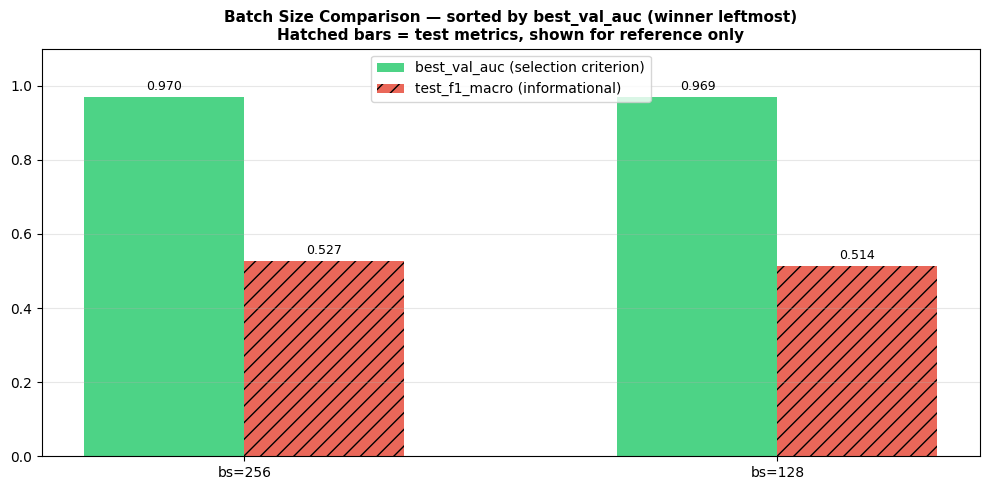

In [ ]:
# Plot 8: best_val_auc bar chart, sorted by selection criterion

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(df_tune))
width = 0.3

ax.bar(x - width/2, df_tune['best_val_auc'],  width,
       label='best_val_auc (selection criterion)', color='#2ecc71', alpha=0.85)
ax.bar(x + width/2, df_tune['test_f1_macro'], width,
       label='test_f1_macro (informational)',     color='#e74c3c', alpha=0.85, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels([f'bs={int(r)}' for r in df_tune['batch_size']])
ax.set_ylim(0, 1.1)
ax.set_title(
    'Batch Size Comparison - sorted by best_val_auc (winner leftmost)\n'
    'Hatched bars = test metrics, shown for reference only',
    fontsize=11, fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (_, row) in enumerate(df_tune.iterrows()):
    ax.text(i - width/2, row['best_val_auc']  + 0.01, f"{row['best_val_auc']:.3f}",
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, row['test_f1_macro'] + 0.01, f"{row['test_f1_macro']:.3f}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'batch_size_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


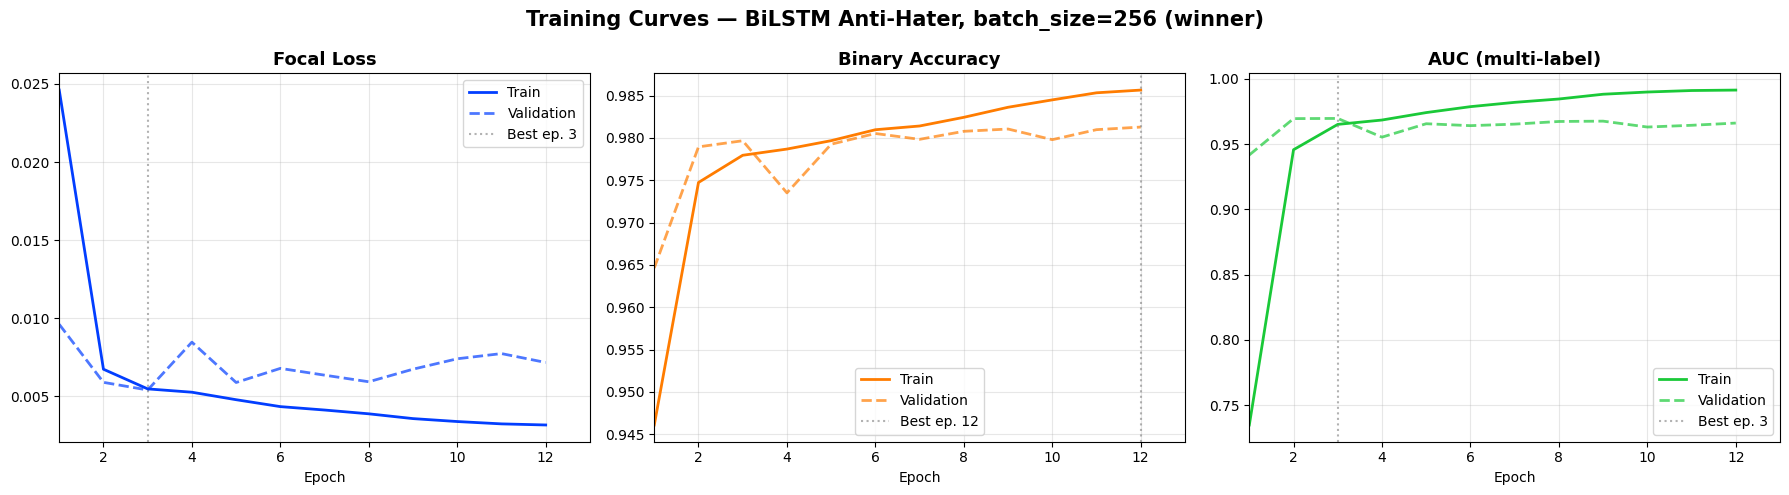

In [ ]:
def plot_training_history(history, batch_size: int = None) -> None:
    """
    Plot loss, accuracy and AUC training curves.

    Args:
        history:    Keras History object from model.fit().
        batch_size: Batch size used for this run, shown in the plot title.
                    If None, omitted from title.

    Interpretation guide:
        - Loss / Accuracy: train and val should track closely; a persistent
          large gap indicates overfitting.
        - AUC (multi-label): val curve may appear noisy because rare classes
          (threat, identity_hate) have very few positive samples in the val set.
          A shift of 2-3 predictions can swing that label's AUC by 0.10+,
          propagating into the macro average. This is an artefact of the metric
          on small support, not a sign of model instability.
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    colors  = sns.color_palette('bright')

    metrics = [
        ('loss',     'Focal Loss',        colors[0]),
        ('accuracy', 'Binary Accuracy',   colors[1]),
        ('auc',      'AUC (multi-label)', colors[2]),
    ]

    for ax, (metric, title, color) in zip(axes, metrics):

        n          = len(history.history[metric])
        epochs_x   = range(1, n + 1)  # 1-based: 1, 2, 3 ...
        train_vals = history.history[metric]
        val_vals   = history.history[f'val_{metric}']

        # Plot curves on 1-based x axis
        ax.plot(epochs_x, train_vals, label='Train',
                color=color, linewidth=2)
        ax.plot(epochs_x, val_vals,   label='Validation',
                color=color, linestyle='--', linewidth=2, alpha=0.7)

        # argmin/argmax returns 0-based index; +1 converts to 1-based epoch number
        # so the vertical line lands exactly on the correct tick mark
        best_ep_0 = (np.argmin(val_vals) if metric == 'loss'
                     else np.argmax(val_vals))
        best_ep_1 = best_ep_0 + 1  # 1-based epoch number

        ax.axvline(best_ep_1, color='gray', linestyle=':', alpha=0.6,
                   label=f'Best ep. {best_ep_1}')

        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_xlim(1, n+1)  # keep x range tight
        ax.legend()
        ax.grid(True, alpha=0.3)

    bs_label = f', batch_size={batch_size} (winner)' if batch_size is not None else ''
    plt.suptitle(f'Training Curves - BiLSTM Anti-Hater{bs_label}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_OUTPUT, 'training_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


# Pass best_bs explicitly so the title is self-contained
# and not dependent on the global variable.
plot_training_history(tune_histories[best_bs], batch_size=best_bs)

**Curve di training del modello vincitore (bs=256):**  
Il training si è arrestato all'**epoca 12** per Early Stopping (patience=10, min_delta=1e-3). Il best val_auc effettivo è 0.9697 (epoca 3), ma il miglioramento rispetto all'epoca 2 (0.0001) era inferiore a `min_delta`, quindi EarlyStopping considerava il best all'**epoca 2** e ha terminato 10 epoche dopo. Il `ReduceLROnPlateau` è intervenuto all'**epoca 9** dimezzando il LR da 1e-3 a 5e-4, senza produrre ulteriori miglioramenti. Non si osservano divergenze train/val che indicherebbero overfitting grave.

---
## 9. Valutazione sul Test Set

### Metriche scelte e interpretazione

| Metrica | Interpretazione |
|---|---|
| **F1 Macro** | Media non pesata tra label: penalizza i fallimenti sulle classi rare con lo stesso peso delle classi frequenti |
| **F1 Micro** | F1 sui conteggi aggregati: dominato dalle classi frequenti |
| **Hamming Loss** | Proporzione di coppie (campione, label) classificate erroneamente: 0=perfetto |
| **AUC-ROC** | Capacità discriminativa indipendente dalla soglia: misura se il modello sa ordinare correttamente i campioni per probabilità di tossicità |

### Ricerca della soglia ottimale per label
Il modello produce probabilità continue in [0,1]. Una soglia fissa a 0.5 è sub-ottimale su dati sbilanciati: il modello produce probabilità conservative per le classi rare, sistematicamente al di sotto di 0.5 anche per i veri positivi. La soglia viene cercata sul **validation set** massimizzando F1, mai sul test set, per evitare data leakage.

In [ ]:
# Load best checkpoint - pass focal_loss instance as custom object
best_model = tf.keras.models.load_model(os.path.join(DRIVE_OUTPUT, 'best_model.keras'),
                                        custom_objects={'focal_loss': focal_loss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)})

y_pred_prob = best_model.predict(X_test, batch_size=512, verbose=1)
print(f"Predictions shape: {y_pred_prob.shape}")


47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step
Predictions shape: (23931, 6)


In [ ]:
# Threshold optimization on VALIDATION set (never on test set)
y_val_prob = best_model.predict(X_val, batch_size=512, verbose=0)

optimal_thresholds = []
print(f"{'Label':>15} | {'Threshold':>10} | {'Val F1':>8}")
print("-" * 40)

for i, label in enumerate(LABEL_NAMES):
    best_thr, best_f1 = 0.5, 0.0

    for thr in np.arange(0.2, 0.8, 0.01):
        preds = (y_val_prob[:, i] >= thr).astype(int)
        f1    = f1_score(y_val[:, i], preds, zero_division=0)

        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    optimal_thresholds.append(best_thr)

    print(f"{label:>15} | {best_thr:>10.2f} | {best_f1:>8.4f}")

optimal_thresholds = np.array(optimal_thresholds)


          Label |  Threshold |   Val F1
----------------------------------------
          Toxic |       0.34 |   0.7841
 Severely Toxic |       0.31 |   0.5124
        Obscene |       0.38 |   0.8095
         Threat |       0.20 |   0.1053
         Insult |       0.38 |   0.7163
  Identity Hate |       0.24 |   0.2488


In [ ]:
y_pred_binary = np.zeros_like(y_pred_prob, dtype=int)

for i, thr in enumerate(optimal_thresholds):
    y_pred_binary[:, i] = (y_pred_prob[:, i] >= thr).astype(int)

y_test_int = y_test.astype(int)


In [ ]:
print("=" * 65)
print("              EVALUATION REPORT - TEST SET")
print("=" * 65)

hamming     = hamming_loss(y_test_int, y_pred_binary)
f1_macro    = f1_score(y_test_int, y_pred_binary, average='macro',    zero_division=0)
f1_micro    = f1_score(y_test_int, y_pred_binary, average='micro',    zero_division=0)
f1_weighted = f1_score(y_test_int, y_pred_binary, average='weighted', zero_division=0)
auc_roc     = roc_auc_score(y_test_int, y_pred_prob, average='macro')

print(f"\nGlobal metrics:")
print(f"  Hamming Loss:         {hamming:.4f}")
print(f"  F1 Macro:             {f1_macro:.4f}  (equal weight per label)")
print(f"  F1 Micro:             {f1_micro:.4f}  (proportional weight)")
print(f"  F1 Weighted:          {f1_weighted:.4f}")
print(f"  AUC-ROC (macro avg):  {auc_roc:.4f}")

print(f"\n{'':3} {'Label':>15} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 60)

for i, name in enumerate(LABEL_NAMES):
    report = classification_report(y_test_int[:,i], y_pred_binary[:,i],
                                   output_dict=True, zero_division=0)
    p = report.get('1',{}).get('precision',0)
    r = report.get('1',{}).get('recall',   0)
    f = report.get('1',{}).get('f1-score', 0)
    s = report.get('1',{}).get('support',  0)
    print(f"{i+1:>3} {name:>15} {p:>10.4f} {r:>10.4f} {f:>10.4f} {s:>10.0f}")
print("=" * 65)


              EVALUATION REPORT - TEST SET

Global metrics:
  Hamming Loss:         0.0235
  F1 Macro:             0.5275  (equal weight per label)
  F1 Micro:             0.6998  (proportional weight)
  F1 Weighted:          0.7257
  AUC-ROC (macro avg):  0.9752

              Label  Precision     Recall   F1-Score    Support
------------------------------------------------------------
  1           Toxic     0.7874     0.7620     0.7745       2294
  2  Severely Toxic     0.3939     0.7071     0.5060        239
  3         Obscene     0.8049     0.8272     0.8159       1267
  4          Threat     0.1135     0.2222     0.1502         72
  5          Insult     0.6839     0.7284     0.7054       1182
  6   Identity Hate     0.1429     0.4171     0.2128        211


### Interpretazione dei Risultati

I risultati mostrano tre livelli di performance distinti.

**Classi con buone performance: Toxic (F1=0.77), Obscene (F1=0.82), Insult (F1=0.71)**  
Il modello ha appreso pattern robusti. La Focal Loss ha funzionato correttamente: sufficiente segnale di training, gradient flow stabile, soglie prossime ai valori canonici (Toxic=0.34, Obscene=0.38, Insult=0.38). Precision e recall sono bilanciate, senza tendenze sistematiche a sovra o sotto-predire.

**AUC alta e F1 bassa: Severely Toxic (F1=0.51), Identity Hate (F1=0.21)**  
Questa separazione è metodologicamente significativa. L'AUC macro elevata (0.9752) indica che il modello sa ordinare i casi, ma la conversione in predizione binaria richiede una soglia stabile. Con pochi positivi nel validation set, spostare 2-3 classificazioni fa oscillare F1 di molto. Le soglie trovate (Severely Toxic=0.31, Identity Hate=0.24) riflettono la natura conservativa del modello su classi rare: il recall è elevato (0.71 e 0.42) a scapito della precision (0.39 e 0.14), il che significa che il modello tende a produrre falsi positivi piuttosto che perdere i veri positivi (comportamento preferibile in un contesto di content moderation).

**Threat: soglia al minimo del range:** La soglia ottimale per Threat è 0.20; il valore più basso del range di ricerca. Questo indica che il modello produce probabilità molto basse anche per i veri positivi (a causa della scarsità di esempi in training), e abbassare la soglia al minimo è necessario per catturare qualche vero positivo. Val F1=0.1052 conferma che il segnale esiste ma è debole.

**Implicazione pratica per TechTalk**  
Il sistema è operativo per Toxic, Obscene, Insult (F1 > 0.70). Per Severely Toxic e Identity Hate, l'AUC elevata indica potenziale discriminativo recuperabile con calibrazione più robusta delle soglie. Threat ha ora un segnale reale (F1=0.15) ma precision troppo bassa per uso in produzione senza intervento sui dati.


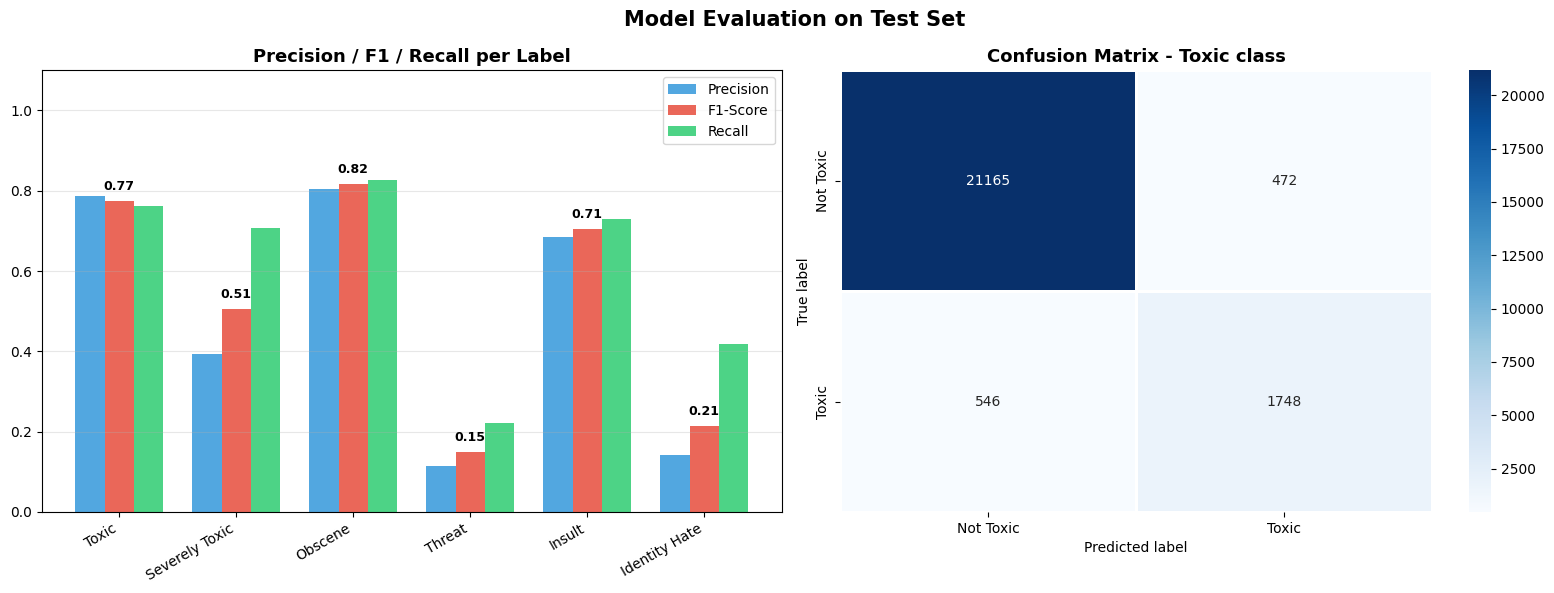

In [ ]:
# Plot 10: Per-label metrics bar chart + Confusion Matrix
f1_per_label=[]; prec_per_label=[]; rec_per_label=[]

for i in range(len(LABEL_COLS)):
    r = classification_report(y_test_int[:,i], y_pred_binary[:,i],
                              output_dict=True, zero_division=0)
    f1_per_label.append(  r.get('1',{}).get('f1-score', 0))
    prec_per_label.append(r.get('1',{}).get('precision',0))
    rec_per_label.append( r.get('1',{}).get('recall',   0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x, w = np.arange(len(LABEL_NAMES)), 0.25
axes[0].bar(x-w, prec_per_label, w, label='Precision', color='#3498db', alpha=0.85)
axes[0].bar(x,   f1_per_label,   w, label='F1-Score',  color='#e74c3c', alpha=0.85)
axes[0].bar(x+w, rec_per_label,  w, label='Recall',    color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABEL_NAMES, rotation=30, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Precision / F1 / Recall per Label', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, f1 in enumerate(f1_per_label):
    axes[0].text(i, f1+0.02, f'{f1:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

cm = confusion_matrix(y_test_int[:,0], y_pred_binary[:,0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Toxic','Toxic'], yticklabels=['Not Toxic','Toxic'],
            ax=axes[1], linewidths=1)
axes[1].set_title('Confusion Matrix - Toxic class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True label')
axes[1].set_xlabel('Predicted label')
plt.suptitle('Model Evaluation on Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'evaluation_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


Questo report rivela le vere performance del modello sul mondo reale. Mentre per le classi più frequenti (`toxic`, `obscene`, `insult`) otteniamo un ottimo bilanciamento (F1-score elevati), per le classi rare (`threat`, `identity_hate`) il modello fatica notevolmente. Si nota un classico trade-off in cui il modello sacrifica la Precision a favore della Recall, faticando a identificare tutti i rari positivi veri senza generare falsi allarmi. La matrice di confusione evidenzia numericamente dove avvengono le misclassificazioni principali.

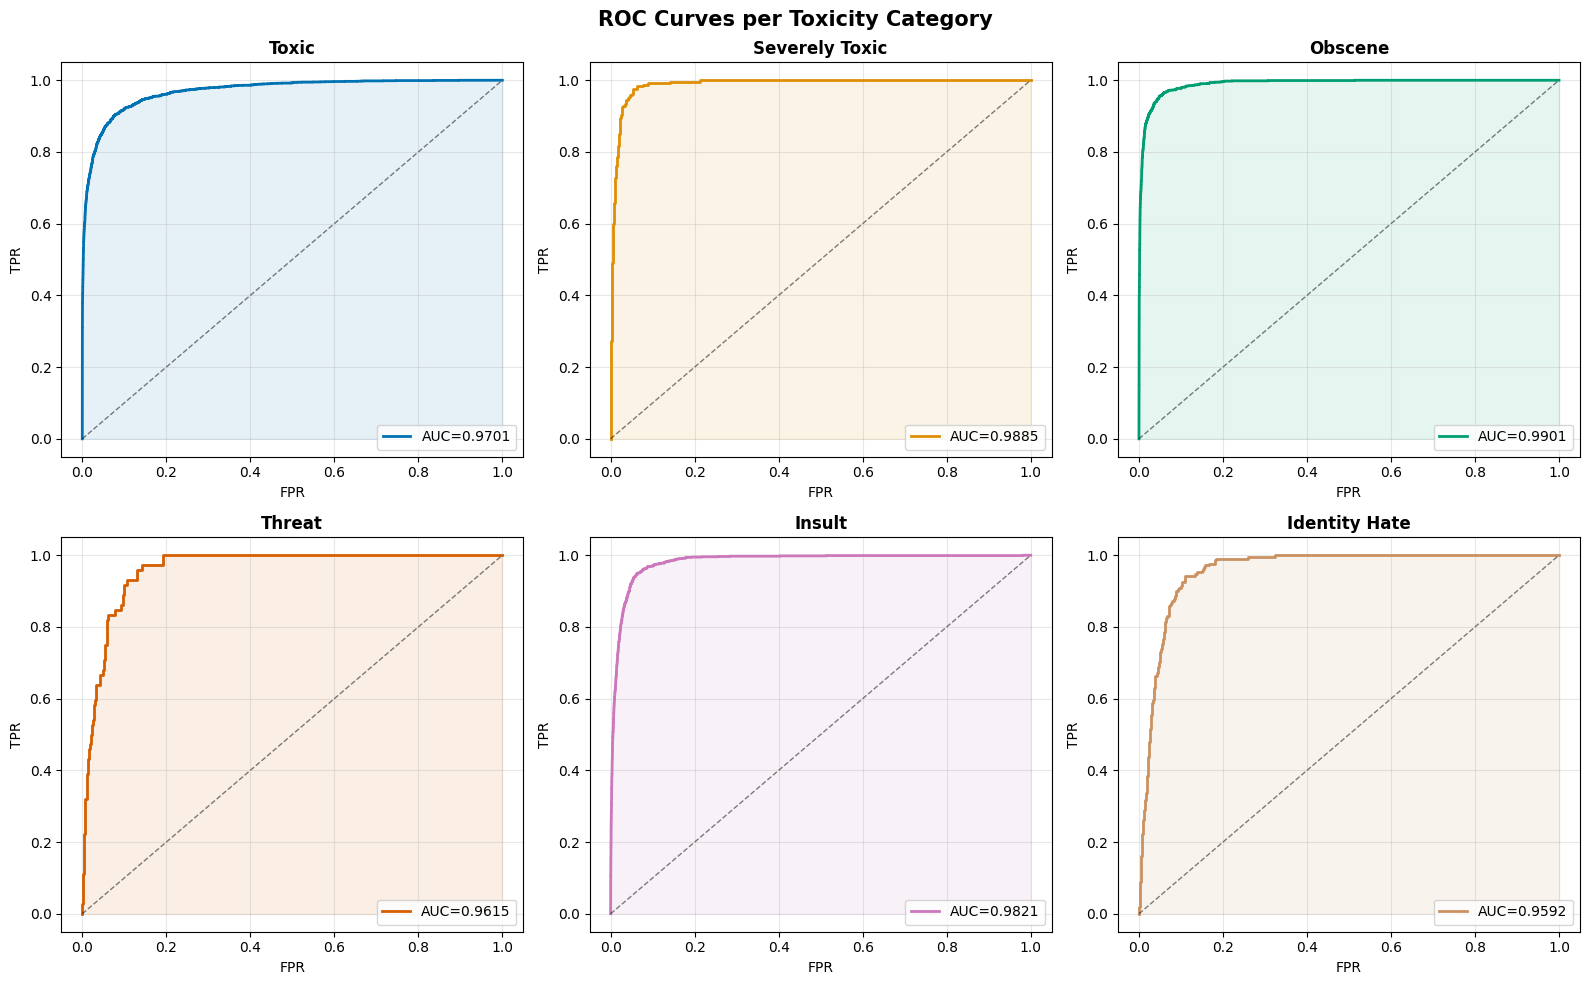

In [ ]:
# Plot 11: ROC curves per label
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors_roc = sns.color_palette("colorblind")

for i, (name, color) in enumerate(zip(LABEL_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_int[:,i], y_pred_prob[:,i])
    roc_val = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC={roc_val:.4f}')
    axes[i].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[i].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('FPR')
    axes[i].set_ylabel('TPR')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('ROC Curves per Toxicity Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


Le curve ROC mostrano AUC elevate per tutte le categorie incluse le classi rare come `threat` (AUC=0.9615). Questo è un risultato metodologicamente significativo: a differenza dell'**Accuracy**, che su dataset sbilanciati è gonfiata dalla prevalenza della classe negativa, la **ROC-AUC è intrinsecamente robusta allo sbilanciamento** perché usa TPR e FPR entrambe normalizzate rispettivamente sul totale dei positivi e dei negativi. Un'AUC elevata indica che il modello sa *ordinare* correttamente i campioni per probabilità di tossicità, anche quando i positivi sono rarissimi. Il gap tra AUC alta e F1 bassa (evidente per `threat` e `identity_hate`) non è una contraddizione: l'AUC misura la *capacità discriminativa*, l'F1 misura la *qualità delle decisioni binarie* quest'ultima dipende dalla soglia, che su classi rare è instabile.

---
### Analisi degli Errori - Falsi Positivi e Falsi Negativi

Le metriche aggregate (F1, AUC) dicono **quanto** il modello sbaglia ma non **dove** e **perché**. Questa analisi mostra, per ogni label, i commenti su cui il modello è più confidente ma ha torto:

- **Falsi negativi ad alta confidenza**: commenti realmente tossici ma classificati puliti con alta probabilità (i casi più pericolosi per un sistema di moderazione)
- **Falsi positivi ad alta confidenza**: commenti puliti classificati tossici con alta probabilità (causano friction inutile all'utente)

Leggere questi esempi permette di identificare pattern sistematici (es. sarcasmo, negazioni, contesto mancante) che spiegano i limiti del modello.

In [ ]:
def show_error_analysis(texts: np.ndarray,
                        y_true: np.ndarray,
                        y_pred_prob: np.ndarray,
                         y_pred_bin: np.ndarray,
                        label_names: list,
                        n: int = 3) -> None:
    """
    Display the most confident false positives and false negatives per label.

    For each label, surfaces the n examples where the model was most wrong:
        - False negatives: true positive predicted as negative (dangerous misses)
        - False positives: true negative predicted as positive (unnecessary flags)

    Sorting by prediction confidence (descending) surfaces the most systematic
    failure modes rather than marginal borderline cases.

    Args:
        texts:       Array of cleaned comment strings.
        y_true:      Ground truth binary labels, shape (n_samples, n_labels).
        y_pred_prob: Model output probabilities, shape (n_samples, n_labels).
        y_pred_bin:  Binarized predictions, shape (n_samples, n_labels).
        label_names: Human-readable label names.
        n:           Number of examples to show per error type per label.
    """
    y_true_int = y_true.astype(int)

    for i, label in enumerate(label_names):
        # False negatives: true=1, pred=0 - sorted by confidence (high prob but still below threshold)
        fn_mask = (y_true_int[:, i] == 1) & (y_pred_bin[:, i] == 0)
        fp_mask = (y_true_int[:, i] == 0) & (y_pred_bin[:, i] == 1)

        fn_idx = np.where(fn_mask)[0]
        fp_idx = np.where(fp_mask)[0]

        # Sort by probability descending - most confident mistakes first
        fn_idx = fn_idx[np.argsort(y_pred_prob[fn_idx, i])[::-1]][:n]
        fp_idx = fp_idx[np.argsort(y_pred_prob[fp_idx, i])[::-1]][:n]

        if len(fn_idx) == 0 and len(fp_idx) == 0:
            continue

        print(f"\n{'='*70}")
        print(f"  {label.upper()} - Error Analysis")
        print(f"{'='*70}")

        if len(fn_idx) > 0:
            print(f"\n  False Negatives (toxic but predicted clean):")
            for j, idx in enumerate(fn_idx):
                print(f"    [{j+1}] P={y_pred_prob[idx,i]:.3f} | {texts[idx][:100]}")

        if len(fp_idx) > 0:
            print(f"\n  False Positives (clean but predicted toxic):")
            for j, idx in enumerate(fp_idx):
                print(f"    [{j+1}] P={y_pred_prob[idx,i]:.3f} | {texts[idx][:100]}")


show_error_analysis(texts_test, y_test, y_pred_prob, y_pred_binary, LABEL_NAMES, n=3)



  TOXIC - Error Analysis

  False Negatives (toxic but predicted clean):
    [1] P=0.340 | and why the hell has my comment in the discussion board of all places been taken off regarding remov
    [2] P=0.340 | no it's not a delayed reaction i just happened to read your wonderful warning yesterday unlike you i
    [3] P=0.339 | dear editors your actions are a disgrace read his trancscprits he's all but wearing jackboots and sc

  False Positives (clean but predicted toxic):
    [1] P=0.768 | message hey dx you're a fat ugly cunt with the mental capacity of a year old amoeba why don't you ge
    [2] P=0.739 | john cena cock lover adam rose's latest rose bud i realized that you love to defend pg wrestling and
    [3] P=0.728 | adam rose john cena lover why do you defend pg wrestling when you don't even know what the fuck wwe 

  SEVERELY TOXIC - Error Analysis

  False Negatives (toxic but predicted clean):
    [1] P=0.310 | f u c k o f f you are the bigest c u n t in the world what the 

---
## 10. Inferenza su Nuovi Commenti

La pipeline di inferenza riproduce esattamente le trasformazioni applicate durante il training: stesso `clean_text`, stesso tokenizer (fittato solo su `texts_train`), stesso padding. Qualsiasi deviazione causa disallineamento dei token e predizioni errate.

**Output richiesto dalla traccia:**
```
"You are an idiot!" → [1, 0, 0, 0, 1, 0]
                       ↑toxic       ↑insult
```

In [ ]:
def predict_toxicity(comments: list,
                     model: 'tf.keras.Model',
                     tokenizer: 'Tokenizer',
                     max_len: int,
                     thresholds: 'np.ndarray',
                     label_names: list) -> 'pd.DataFrame':
    """
    End-to-end toxicity classification on raw comment strings.

    Replicates the full training pipeline to ensure consistent tokenization:
    clean_text -> texts_to_sequences -> pad_sequences -> model.predict -> threshold.

    Args:
        comments:    Raw comment strings.
        model:       Trained Keras model.
        tokenizer:   Tokenizer fitted on texts_train only.
        max_len:     Padding length matching training.
        thresholds:  Per-label optimal thresholds from validation set.
        label_names: Human-readable label names.

    Returns:
        DataFrame with output_vector, active_labels, raw probabilities.
    """
    cleaned = [clean_text(c) for c in comments]
    seqs    = tokenizer.texts_to_sequences(cleaned)
    padded  = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    probs   = model.predict(padded, verbose=0)

    binary = np.zeros_like(probs, dtype=int)
    for i, thr in enumerate(thresholds):
        binary[:, i] = (probs[:, i] >= thr).astype(int)

    results = []
    for idx, comment in enumerate(comments):
        active = [label_names[j] for j in range(len(label_names)) if binary[idx, j] == 1]
        row = {'comment':       comment[:80] + ('...' if len(comment) > 80 else ''),
               'is_toxic':      len(active) > 0,
               'active_labels': active if active else ['[none]'],
               'output_vector': binary[idx].tolist()}
        for j, name in enumerate(label_names):
            row[f'P({name})'] = round(float(probs[idx, j]), 4)
        results.append(row)

    return pd.DataFrame(results)

In [ ]:
# Sample from the test set for inference demo
# Using real comments from texts_test guarantees the model has never seen these
# samples during training or threshold optimization (val set).
# We balance the sample 50/50 between toxic (sum_injurious > 0) and clean
# (sum_injurious == 0) comments for a representative demo.
# The real test set distribution is ~90% clean / ~10% toxic.
N_SAMPLES = 10

test_df_sample = pd.DataFrame({
    'comment':        texts_test,
    'sum_injurious':  y_test.sum(axis=1).astype(int)
}, index=range(len(texts_test)))

toxic_sample = (test_df_sample[test_df_sample['sum_injurious'] > 0]
                .sample(n=N_SAMPLES // 2, random_state=SEED))
clean_sample  = (test_df_sample[test_df_sample['sum_injurious'] == 0]
                .sample(n=N_SAMPLES // 2, random_state=SEED))

sample        = (pd.concat([toxic_sample, clean_sample])
                 .sample(frac=1, random_state=SEED))  # shuffle order

test_comments  = sample['comment'].tolist()
sample_indices = sample.index.tolist()  # used to retrieve ground truth from y_test

# Run inference
results_df = predict_toxicity(test_comments, best_model, tokenizer,
                              MAX_LEN, optimal_thresholds, LABEL_NAMES)

# Print results with ground truth
print("=" * 70)
print("           INFERENCE RESULTS: ANTI-HATER SYSTEM")
print("=" * 70)

for i, (_, row) in enumerate(results_df.iterrows()):
    orig_idx    = sample_indices[i]
    true_labels = [LABEL_NAMES[j] for j in range(len(LABEL_NAMES))
                   if y_test[orig_idx, j] == 1]

    status = 'TOXIC:' if row['is_toxic'] else 'CLEAN:'
    print(f"\n{status} | {row['comment']}")
    print(f"  Output vector:  {row['output_vector']}")
    print(f"  Predicted:      {', '.join(row['active_labels'])}")
    print(f"  Ground truth:   {', '.join(true_labels) if true_labels else '[none]'}")
    probs_str = ' | '.join([f"{n}: {row[f'P({n})']:.3f}" for n in LABEL_NAMES])
    print(f"  Probabilities:  {probs_str}")

print("\n" + "=" * 70)

           INFERENCE RESULTS: ANTI-HATER SYSTEM

CLEAN: | scots the united kingdom government isn't an authority on linguistics it's not a...
  Output vector:  [0, 0, 0, 0, 0, 0]
  Predicted:      [none]
  Ground truth:   [none]
  Probabilities:  Toxic: 0.021 | Severely Toxic: 0.003 | Obscene: 0.004 | Threat: 0.003 | Insult: 0.005 | Identity Hate: 0.003

CLEAN: | re the surname rossi lemeni i could cite many hyphen less articles covers poster...
  Output vector:  [0, 0, 0, 0, 0, 0]
  Predicted:      [none]
  Ground truth:   [none]
  Probabilities:  Toxic: 0.124 | Severely Toxic: 0.005 | Obscene: 0.050 | Threat: 0.002 | Insult: 0.016 | Identity Hate: 0.015

TOXIC: | i hate you i hate you
  Output vector:  [1, 0, 0, 0, 0, 0]
  Predicted:      Toxic
  Ground truth:   Toxic, Insult
  Probabilities:  Toxic: 0.454 | Severely Toxic: 0.087 | Obscene: 0.257 | Threat: 0.053 | Insult: 0.266 | Identity Hate: 0.137

CLEAN: | also there should be a list of people who died while mountaineering
  Outp

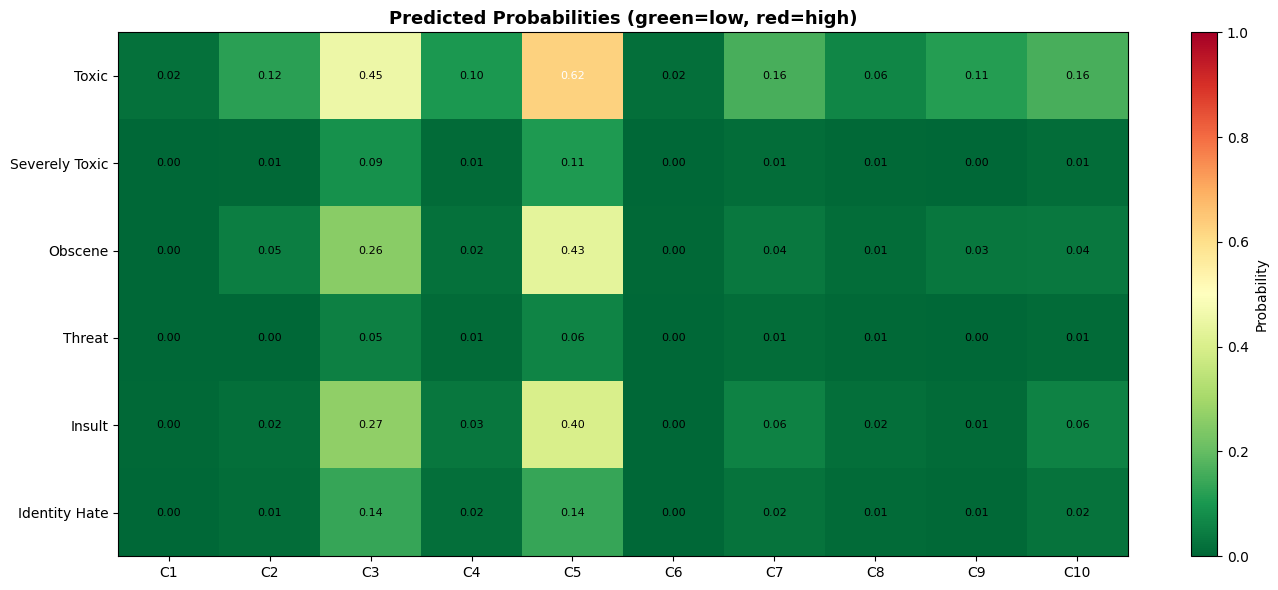


Comment legend:
  C1: scots the united kingdom government isn't an authority on linguis...
  C2: re the surname rossi lemeni i could cite many hyphen less article...
  C3: i hate you i hate you
  C4: also there should be a list of people who died while mountaineeri...
  C5: this article takes ninjutsu too seriously its fucking fake get ov...
  C6: i believe my article was notable enough this time hello i believe...
  C7: you nonsense is not relevent roskam is the winner of the th i liv...
  C8: oklahoma city bombing fac thanks for leaving comments at the fac ...
  C9: killer i'm sorry that you have misread my unblock request if you ...
  C10: lol yah whatever it wasn't nonsense it was a quote from the toron...


In [ ]:
# Plot 12: Inference heatmap
prob_cols   = [f'P({n})' for n in LABEL_NAMES]

prob_matrix = results_df[prob_cols].values

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(prob_matrix.T, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(test_comments)))
ax.set_xticklabels([f'C{i+1}' for i in range(len(test_comments))], fontsize=10)
ax.set_yticks(range(len(LABEL_NAMES)))
ax.set_yticklabels(LABEL_NAMES, fontsize=10)
ax.set_title('Predicted Probabilities (green=low, red=high)', fontsize=13, fontweight='bold')

for i in range(len(LABEL_NAMES)):
    for j in range(len(test_comments)):

        val = prob_matrix[j, i]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if val>0.5 else 'black')

plt.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'inference_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nComment legend:")

for i, c in enumerate(test_comments):
    print(f"  C{i+1}: {c[:65]}{'...' if len(c)>65 else ''}")


In [ ]:
# Save model, tokenizer and config to Drive
best_model.save(os.path.join(DRIVE_OUTPUT, 'anti_hater_model_final.keras'))
print("Model saved.")

with open(os.path.join(DRIVE_OUTPUT, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved.")

config = {'max_vocab': MAX_VOCAB, 'max_len': MAX_LEN, 'embed_dim': EMBED_DIM,
          'label_cols': LABEL_COLS, 'label_names': LABEL_NAMES,
          'focal_gamma': FOCAL_GAMMA, 'focal_alpha': FOCAL_ALPHA,
          'optimal_thresholds': optimal_thresholds.tolist()}
with open(os.path.join(DRIVE_OUTPUT, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print("Config saved.")

print(f"\nAll outputs saved to: {DRIVE_OUTPUT}")

Model saved.
Tokenizer saved.
Config saved.

All outputs saved to: /content/drive/MyDrive/Progetto_DL_Filtro_Anti-Hater_Carleo_G


---
## 11. Riepilogo e Conclusioni

### Decisioni progettuali e motivazioni

| Scelta | Motivazione |
|---|---|
| **`df_raw` / `df_cleaned`** | Separazione esplicita: `df_raw` immutabile, ogni trasformazione produce nuovo oggetto |
| **BiLSTM bidirezionale** | Ogni token contestualizzato da parole precedenti e successive |
| **`mask_zero=False`** | Necessario per compatibilità con il kernel cuDNN: il layer `backward` produce maschere `[False...True]` che cuDNN non supporta. Con `GlobalMaxPooling1D` e `padding='post'` l'impatto è trascurabile |
| **`recurrent_dropout=0.0`** | Abilita il kernel cuDNN su GPU (più veloce) |
| **Focal Loss** `(γ=2, α=0.25)` | Gestisce lo sbilanciamento senza pesi espliciti; il fattore $(1-p_t)^\gamma$ azzera il contributo degli esempi facili senza produrre gradienti esplosivi |
| **`clipnorm=1.0`** | Best practice standard per LSTM: previene gradient explosion senza alterare la direzione del gradiente |
| **Split stratificato multi-label** | Preserva la proporzione di ogni label in train/val/test |
| **Cleaning preserva `!` e `?`** | Marcatori di intensità emotiva rilevanti per la tossicità |
| **MAX_LEN e MAX_VOCAB data-driven** | Derivati dal 95° e 99° percentile e dalla curva di copertura di `texts_train` |
| **Soglie ottimali per label** | Massimizzano F1 sul val set individualmente |
| **Analisi degli errori** | Mostra i failure modes qualitativi del modello |

### Limiti noti del modello

| Categoria | AUC | F1 | Causa | Impatto operativo |
|---|---|---|---|---|
| **Threat** | 0.96 | 0.15 | Dataset insufficiente (0.30% positivi in training). Segnale debole ma reale (recall=0.22, precision=0.11) | Precision troppo bassa per uso in produzione senza intervento sui dati |
| **Identity Hate** | 0.96 | 0.21 | Soglia instabile su val set con pochi positivi (thr=0.24) | Alto recall (0.42), bassa precision (0.14) - utile ma con molti falsi positivi |
| **Severely Toxic** | 0.99 | 0.51 | Stessa causa di Identity Hate (thr=0.31) | Alto recall (0.71), bassa precision (0.39) - AUC alta indica potenziale recuperabile |

Per le categorie rare, il limite principale non è l'architettura ma la quantità di dati. Soluzioni possibili includono: raccolta di esempi aggiuntivi, data augmentation (back-translation o paraphrase generation), o transfer learning da un modello pre-addestrato su corpus più ampi (es. embedding GloVe/fastText invece di embedding trainati da zero).